In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../')

from pathlib import Path

import phys_ml.visualization.vertex_visualization as vertvis
import phys_ml.visualization.base as vis
from phys_ml.analysis.vertex import *
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *
from phys_ml.util import slurm_generate

data_dir = Path('/gpfs/data/fs71925/shepp123/frgs_6d/')
rmse_df = pd.read_csv('reconstruction_results.csv')
classification_df = pd.read_pickle('classification_results.pkl')
regression_df = pd.read_csv('regression_results.csv')

plot_dir = Path('../../../../thesis/images/')

## contents

&emsp;0&emsp;on real space  
&emsp;1&emsp;trained on all vertices  
&emsp;&emsp;1-1&emsp;simple autoencoder  
&emsp;&emsp;1-2&emsp;contrastive autoencoder  
&emsp;2&emsp;trained on only 2 phases  
&emsp;&emsp;2-1&emsp;exclude SC-phase  
&emsp;&emsp;&emsp;2-1-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-1-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-2&emsp;exclude AFM-phase  
&emsp;&emsp;&emsp;2-2-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-2-2&emsp;contrastive autoencoder  
&emsp;&emsp;2-3&emsp;exclude FM-phase  
&emsp;&emsp;&emsp;2-3-1&emsp;simple autoencoder  
&emsp;&emsp;&emsp;2-3-2&emsp;contrastive autoencoder  
&emsp;3&emsp;trained on only 1 phase  
&emsp;&emsp;3-1&emsp;SC-phase  
&emsp;&emsp;3-2&emsp;AFM-phase  
&emsp;&emsp;3-3&emsp;FM-phase  
&emsp;4&emsp;correlation  
&emsp;5&emsp;convergence  

## visualize vertex

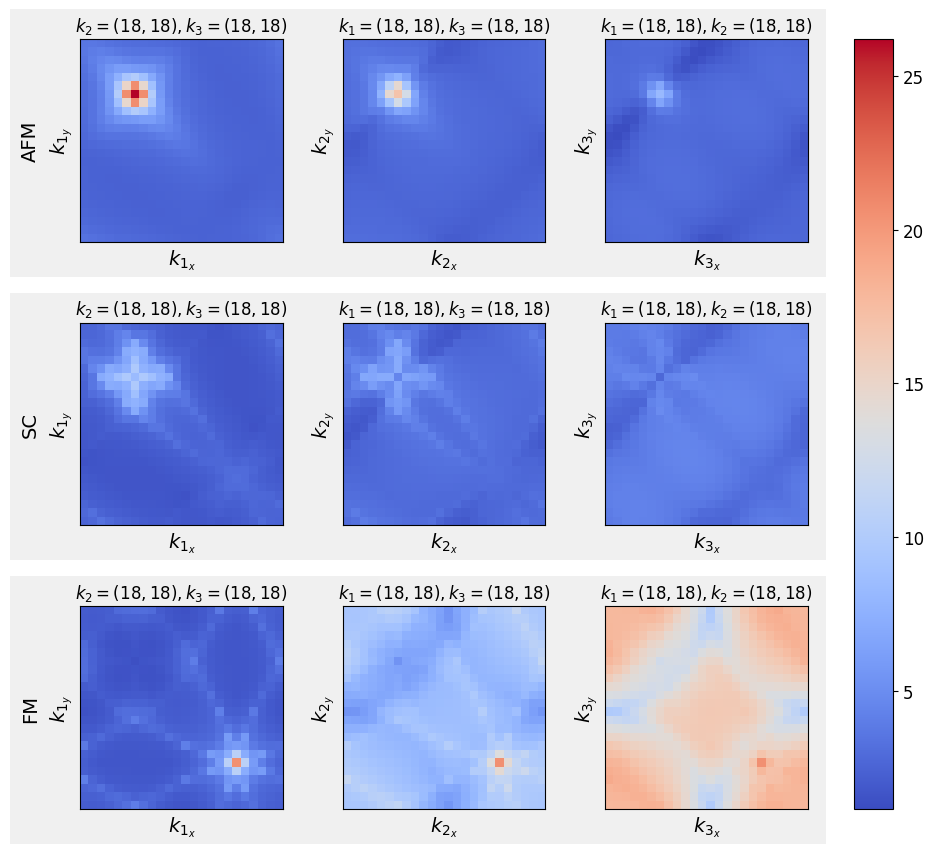

In [116]:
files_names = ['tp0.090000_mu0.360000', 'tp0.270000_mu1.080000', 'tp0.410000_mu1.640000']
vertices = [AutoEncoderVertex24x6Dataset.load_from_file(data_dir / f'{fn}.h5') for fn in files_names]
vertvis.plot_compare_slices(vertices, i=18, axis=3, vmin=None, vmax=None)

## vertex statistics

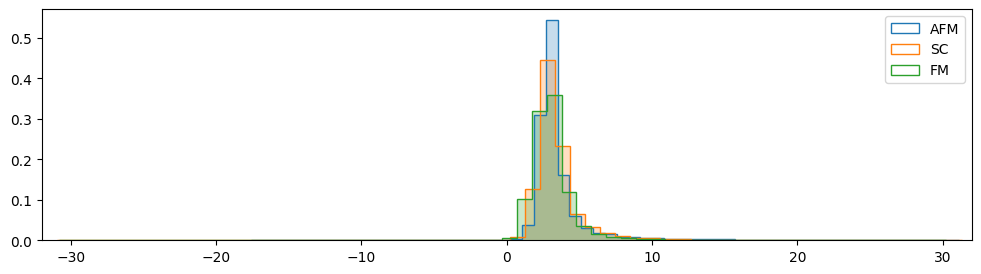

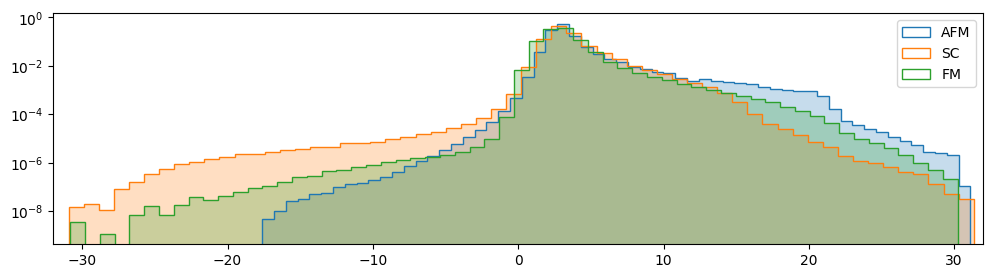

,min,max,mean,sum
AFM,-17.621026,31.116854,3.516467,13440147922.163141
SC,-30.943928,31.344199,3.435302,13129930305.072977
FM,-30.830774,30.236403,3.128338,11956693254.854389


In [3]:
df, data = verteval.vertex_statistics(data_dir)
verteval.plot_statistics(data)
verteval.plot_statistics(data, log=True)
df

## correlation

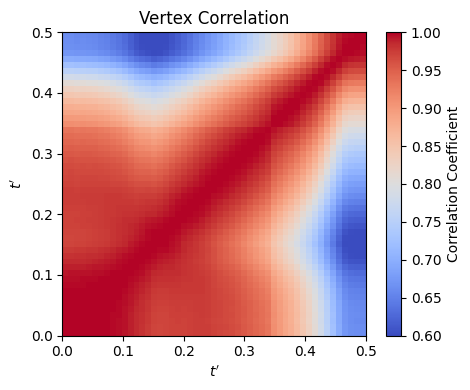

In [5]:
cor_mat = np.load(f'cor_mat_real.npy')
vertvis.plot_correlation(cor_mat, "Vertex Correlation", figsize=(5,4), vmin=0.6, plot_dir=plot_dir, plot_name='vert_corr_real')

In [10]:
cor_mat.min()

np.float64(0.5897979984026432)

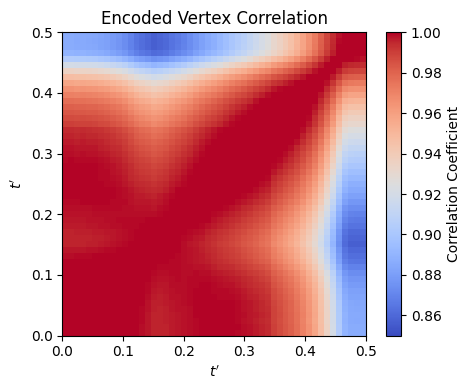

In [7]:
cor_mat = np.load(f'cor_mat_latent_1-1-ld32.npy')
vertvis.plot_correlation(cor_mat, "Encoded Vertex Correlation", vmin=0.85, figsize=(5,4), plot_dir=plot_dir, plot_name='vert_corr_encoded')

In [4]:
cor_mat.min()

np.float64(0.8568989038467407)

## compare autoencoder models

In [2]:
rmse_summary = rmse_df.drop(columns=['tp', 'train_data', 'contrastive', 'train_phase']).groupby(['run_id', 'ld', 's', 'seed']).mean()
rmse_summary['test_rmse_train_phase'] = (rmse_df[~rmse_df['train_data'] & rmse_df['train_phase']]
                                            .drop(columns=['tp', 'train_data', 'contrastive', 'train_phase'])
                                            .groupby(['run_id', 'ld', 's', 'seed']).mean())
rmse_summary['test_rmse_test_phase'] = (rmse_df[~rmse_df['train_data'] & ~rmse_df['train_phase']]
                                            .drop(columns=['tp', 'train_data', 'contrastive', 'train_phase'])
                                            .groupby(['run_id', 'ld', 's', 'seed']).mean())
rmse_summary['train_rmse'] = (rmse_df[rmse_df['train_data']].drop(columns=['tp', 'train_data', 'contrastive', 'train_phase'])
                                                            .groupby(['run_id', 'ld', 's', 'seed']).mean())
rmse_summary

rmse  test_rmse_train_phase  \
run_id     ld s     seed                                    
1_1        32 24000 123   0.007771                    NaN   
1_2        32 24000 123   0.066215                    NaN   
2_1_1      8  24000 123   0.169867               0.110327   
           16 24000 123   0.097626               0.058324   
           20 24000 123   0.074753               0.044556   
           24 24000 123   0.046875               0.026416   
           32 2000  123   0.068156               0.044921   
              8000  123   0.040277               0.023146   
              12000 123   0.047274               0.026910   
              16000 123   0.018830               0.008657   
              24000 123   0.023504               0.013406   
2_1_1_step 32 64000 123   1.549998               1.346414   
2_1_2      32 24000 123   0.043141               0.024098   
2_2_1      32 24000 123   0.011346               0.007191   
2_2_2      32 24000 123   0.050307               0.049067   
2_3_1      32 2000  123   0.074954               0.058237   
              8000  123   0.039510               0.026384   
              24000 89    0.009282               0.008019   
                    106   0.009301               0.009856   
                    123   0.008695               0.007991   
                    140   0.008541               0.008063   
                    157   0.009279               0.008875   
              64000 123   0.007519               0.006533   
2_3_2      32 24000 123   0.067075               0.047465   
3_1        32 24000 123   0.016433               0.009049   
3_2        32 24000 123   0.054052               0.012059   
3_3        32 24000 123   0.019987               0.006524   

                          test_rmse_test_phase  train_rmse  
run_id     ld s     seed                                    
1_1        32 24000 123                    NaN    0.007771  
1_2        32 24000 123                    NaN    0.066215  
2_1_1      8  24000 123               0.273417    0.140872  
           16 24000 123               0.168671    0.077321  
           20 24000 123               0.137733    0.055514  
           24 24000 123               0.093036    0.032327  
           32 2000  123               0.110540    0.055987  
              8000  123               0.077541    0.028698  
              12000 123               0.090472    0.033985  
              16000 123               0.045544    0.009967  
              24000 123               0.047442    0.015824  
2_1_1_step 32 64000 123               1.355508    1.693345  
2_1_2      32 24000 123               0.083902    0.030556  
2_2_1      32 24000 123               0.016933    0.007874  
2_2_2      32 24000 123               0.049049    0.051612  
2_3_1      32 2000  123               0.082734    0.074069  
              8000  123               0.049277    0.036283  
              24000 89                0.010098    0.009058  
                    106               0.009988    0.008675  
                    123               0.008787    0.008820  
                    140               0.008163    0.008931  
                    157               0.009063    0.009537  
              64000 123               0.008014    0.007442  
2_3_2      32 24000 123               0.078320    0.064569  
3_1        32 24000 123               0.018667    0.010156  
3_2        32 24000 123               0.079995    0.014287  
3_3        32 24000 123               0.026567    0.008324

### to latex

In [15]:
rs = rmse_summary.reset_index()
rs = rs.merge(rmse_df[['run_id', 'ld', 's', 'contrastive']].drop_duplicates(), on=['run_id', 'ld', 's'])
# rs = rs.rename(columns={'run_id': 'scenario', 'rmse': 'RMSE (all)', 'train_rmse': 'RMSE (train)',
#                         'test_rmse_train_phase': 'RMSE (test vertices from train phase)', 'test_rmse_test_phase': 'RMSE (test phase)'})
rs = rs[['run_id', 'ld', 's', 'contrastive', 'rmse', 'test_rmse_train_phase', 'test_rmse_test_phase']]

print(rs[~rs['contrastive'] & (rs['ld'] == 32) & (rs['s'] == 24000)]
        .drop(columns=['ld', 's', 'contrastive'])
        .to_latex(index=False, float_format="%.3f"))

print(rs[rs['contrastive'] & (rs['ld'] == 32) & (rs['s'] == 24000)]
        .drop(columns=['ld', 's', 'contrastive'])
        .to_latex(index=False, float_format="%.3f"))

print(rs[(rs['run_id'] == '2_1_1') & (rs['s'] == 24000)]
        .drop(columns=['s', 'contrastive'])
        .to_latex(index=False, float_format="%.3f"))

print(rs[(rs['run_id'] == '2_1_1') & (rs['ld'] == 32)]
        .drop(columns=['ld', 'contrastive'])
        .to_latex(index=False, float_format="%.3f"))

\begin{tabular}{lrrr}
\toprule
run_id & rmse & test_rmse_train_phase & test_rmse_test_phase \\
\midrule
1_1 & 0.008 & NaN & NaN \\
2_1_1 & 0.024 & 0.013 & 0.047 \\
2_2_1 & 0.011 & 0.007 & 0.017 \\
2_3_1 & 0.009 & 0.008 & 0.010 \\
2_3_1 & 0.009 & 0.010 & 0.010 \\
2_3_1 & 0.024 & 0.015 & 0.035 \\
2_3_1 & 0.009 & 0.008 & 0.008 \\
2_3_1 & 0.009 & 0.009 & 0.009 \\
3_1 & 0.016 & 0.009 & 0.019 \\
3_2 & 0.054 & 0.012 & 0.080 \\
3_3 & 0.020 & 0.007 & 0.027 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrr}
\toprule
run_id & rmse & test_rmse_train_phase & test_rmse_test_phase \\
\midrule
1_2 & 0.066 & NaN & NaN \\
2_1_2 & 0.043 & 0.024 & 0.084 \\
2_2_2 & 0.050 & 0.049 & 0.049 \\
2_3_2 & 0.067 & 0.047 & 0.078 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrr}
\toprule
run_id & ld & rmse & test_rmse_train_phase & test_rmse_test_phase \\
\midrule
2_1_1 & 8 & 0.170 & 0.110 & 0.273 \\
2_1_1 & 16 & 0.098 & 0.058 & 0.169 \\
2_1_1 & 20 & 0.075 & 0.045 & 0.138 \\
2_1_1 & 24 & 0.047 & 0.026 & 0.093 \\


### training data subset analysis

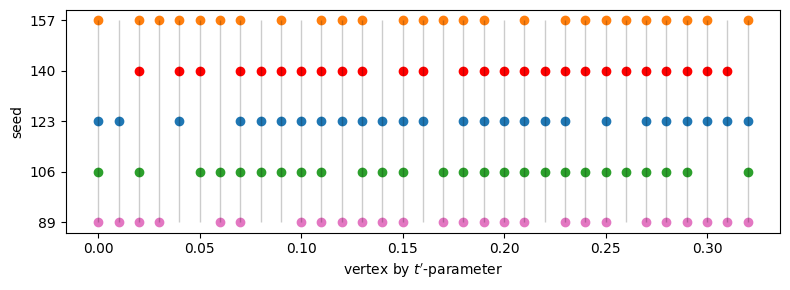

In [8]:
# compare selected vertices per seed

import matplotlib.pyplot as plt

df = rmse_df[(rmse_df['run_id'] == '2_3_1') & (rmse_df['ld'] == 32) & (rmse_df['s'] == 24000) & rmse_df['train_data']]
seeds = df['seed'].sort_values().unique()

fig, ax = plt.subplots(figsize=(8,3))
ax.vlines(np.arange(0., 0.33, 0.01), ymin=min(seeds), ymax=max(seeds), lw=1, color='k', alpha=0.2)
for i, seed in enumerate(seeds):
    df_seed = df[df['seed'] == seed]
    ax.scatter(df_seed['tp'], [seed] * len(df_seed), marker='o', color=vis.COLORS[i])
ax.set_xlabel("vertex by $t'$-parameter")
ax.set_ylabel('seed')
ax.set_yticks(seeds)
plt.tight_layout()
plt.show()

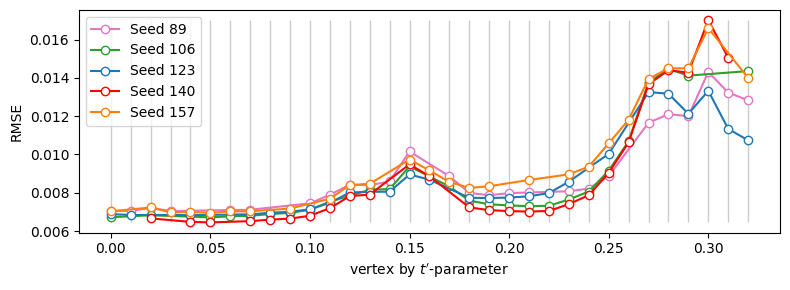

In [9]:
subset = df = rmse_df[(rmse_df['run_id'] == '2_3_1') & (rmse_df['ld'] == 32) & (rmse_df['s'] == 24000) & rmse_df['train_data']]
verteval.plot_rmse_per_vertex_and_seed(subset, plot_dir=plot_dir, plot_name='ae_rmse_seed')

### Reconstruction error analysis

In [ ]:
base_dir = Path('/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results_2')
plot_data = [('2_1_1_ld32', [0.03, 0.3]), 
             ('2_2_1_ld32', [0.01, 0.15]), 
             ('2_3_1_ld32', [0.42, 0.3]), 
             ('2_1_1_step_s64000', [0.06, 0.17, 0.47])]
vertex_data = verteval.load_vertices(plot_data, data_dir, base_dir)

2_1_1_ld32, tp=0.03


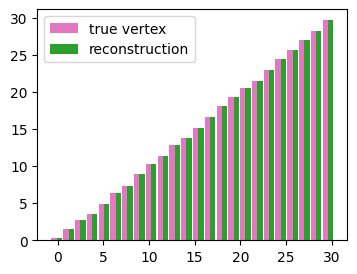

2_1_1_ld32, tp=0.30


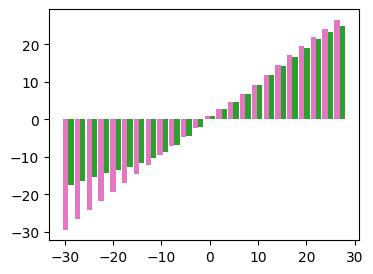

2_2_1_ld32, tp=0.01


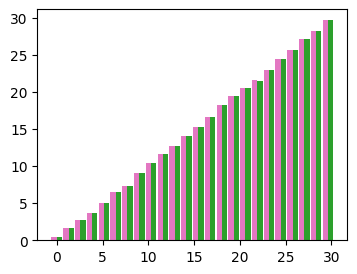

2_2_1_ld32, tp=0.15


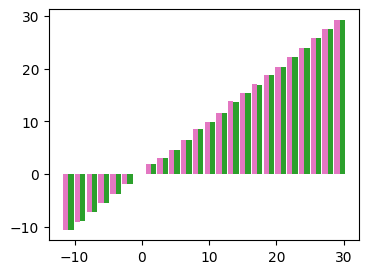

2_3_1_ld32, tp=0.42


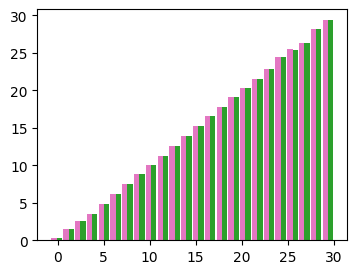

2_3_1_ld32, tp=0.30


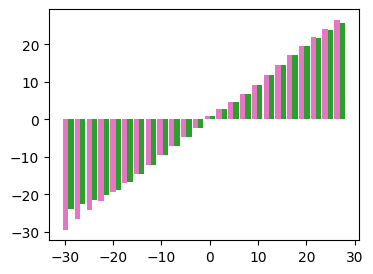

2_1_1_step_s64000, tp=0.06


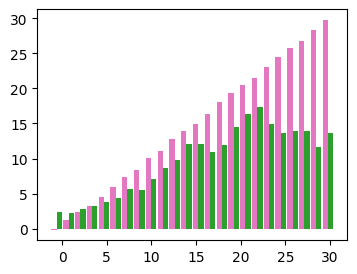

2_1_1_step_s64000, tp=0.17


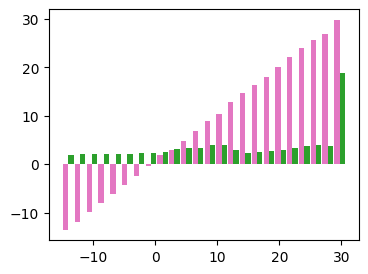

2_1_1_step_s64000, tp=0.47


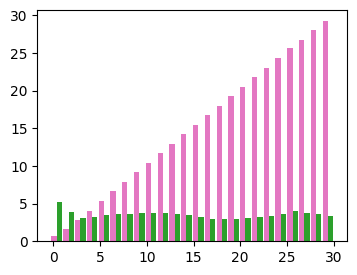

In [ ]:
for i, (vertex, pred, run_id, tp) in enumerate(vertex_data[:-1]):
    print(f"{run_id}, $t'={tp:.2f}$")
    verteval.plot_vertex_error(vertex, pred, bars=True, predict=False, nbins=24, legend=i==0, plot_name=f'reconst_{run_id}_tp{tp:.2f}')

vertex, pred, run_id, tp = vertex_data[-1]
verteval.plot_vertex_error(vertex, pred, bars=True, predict=True, nbins=24, legend=i==0, plot_name=f'reconst_{run_id}_tp{tp:.2f}')

In [20]:
plot_data = [('2_1_1', 32, 24000, [0.03, 0.3]), 
             ('2_2_1', 32, 24000, [0.01, 0.15]), 
             ('2_3_1', 32, 24000, [0.42, 0.3]), 
             ('2_1_1_step', 32, 64000, [0.06, 0.17, 0.47])]

dfs = []
for run_id, ld, s, tps in plot_data:
    dfs.append(rmse_df[(rmse_df["run_id"] == run_id) 
                       & (rmse_df["ld"] == ld) 
                       & (rmse_df["s"] == s) 
                       & (rmse_df["seed"] == 123)
                       & rmse_df["tp"].isin(tps)])
pd.concat(dfs)

,tp,rmse,train_data,run_id,ld,s,seed,contrastive,train_phase
54,0.03,0.006572,False,2_1_1,32,24000,123,False,True
81,0.30,0.064287,False,2_1_1,32,24000,123,False,False
1173,0.01,0.007615,False,2_2_1,32,24000,123,False,False
1187,0.15,0.037681,False,2_2_1,32,24000,123,False,False
1355,0.30,0.013327,True,2_3_1,32,24000,123,False,True
1367,0.42,0.006231,False,2_3_1,32,24000,123,False,False
311,0.06,0.919364,False,2_1_1_step,32,64000,123,False,True
322,0.17,2.515553,False,2_1_1_step,32,64000,123,False,True
352,0.47,3.042255,True,2_1_1_step,32,64000,123,False,True


### RMSEs per scenario (all test data)

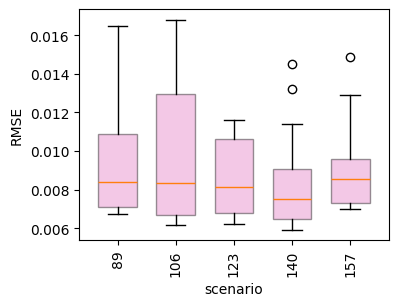

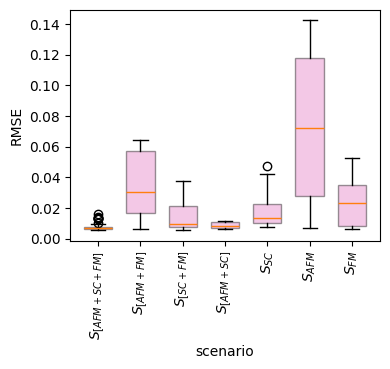

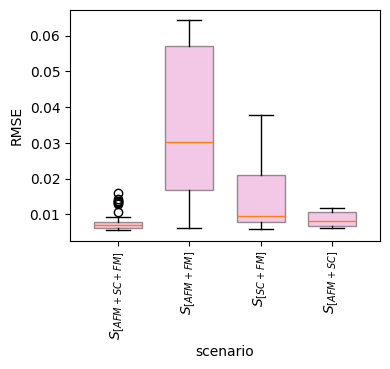

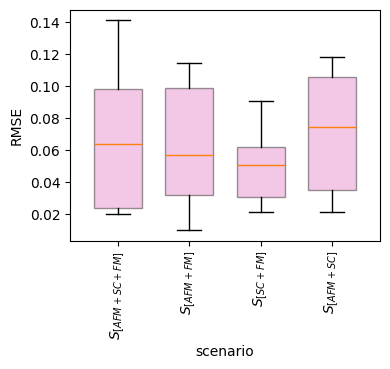

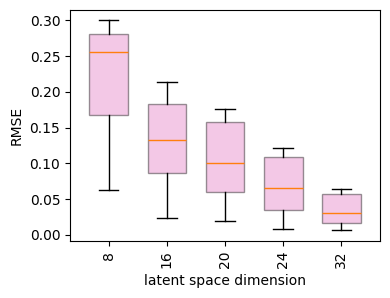

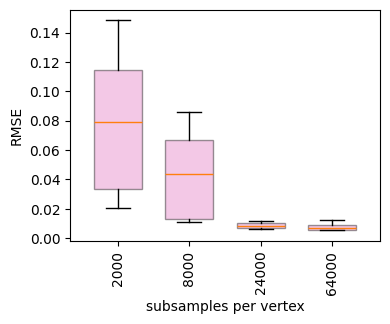

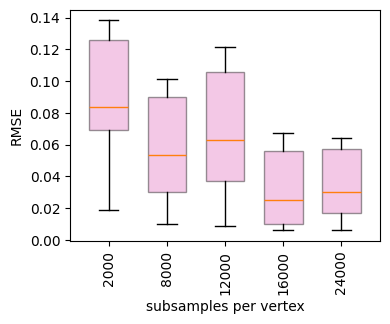

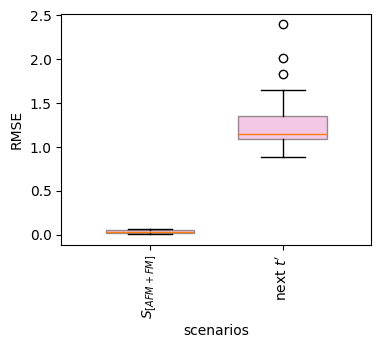

In [6]:
verteval.plot_rmse_boxplots(rmse_df, figsize=(4, 3), train_data=False, plot_dir=None)

### RMSEs per scenario (test data, train phases)

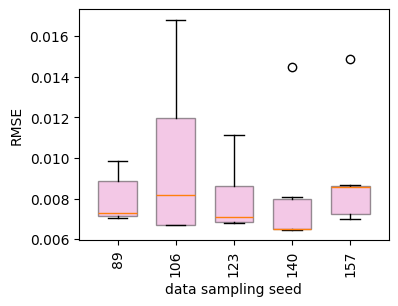

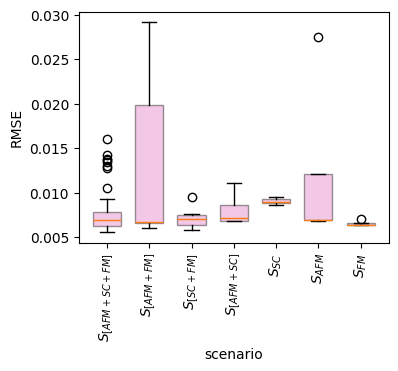

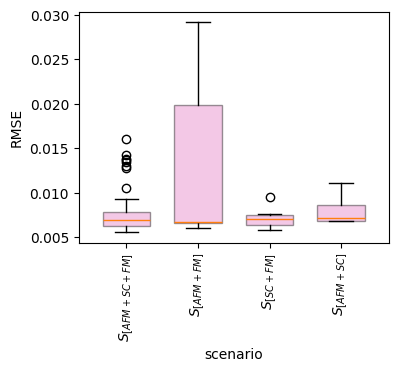

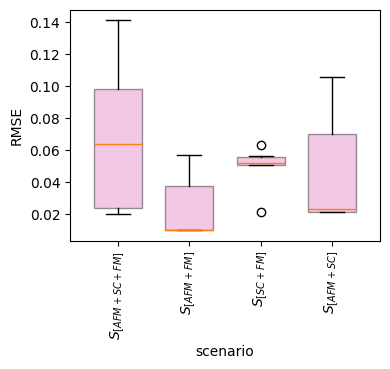

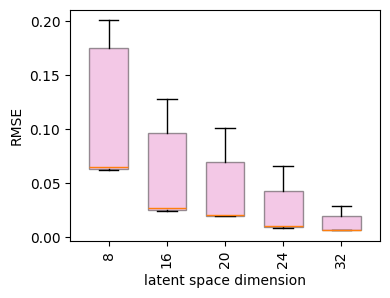

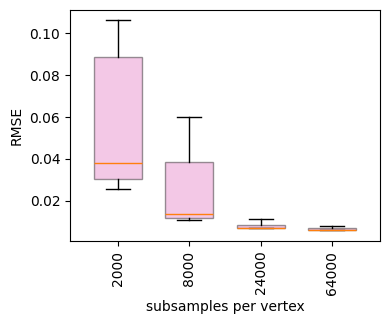

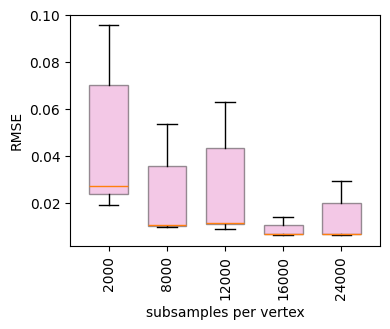

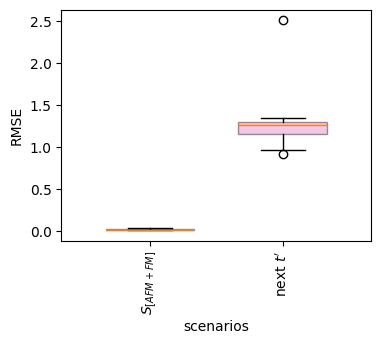

In [3]:
# train vertices only
df = rmse_df.copy()
df = df[df['run_id'].str.startswith('1_') | (~df['train_data'] & df['train_phase'])]
verteval.plot_rmse_boxplots(df, figsize=(4, 3), train_data=False, plot_dir=plot_dir, plot_name='ae_res1')

### RMSEs per scenario (test data, unseen phases)

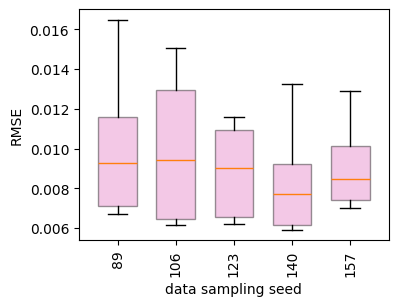

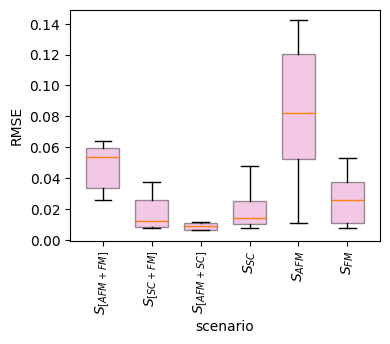

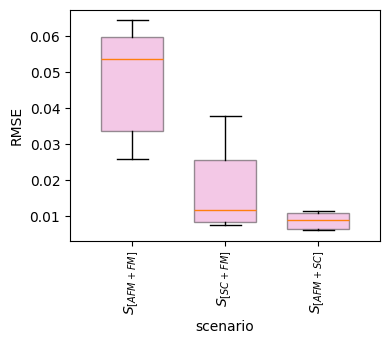

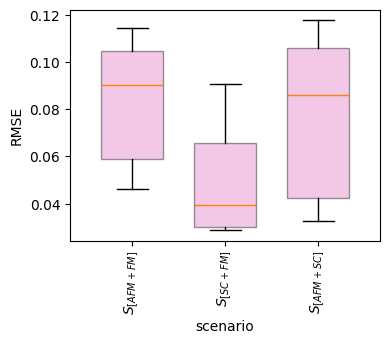

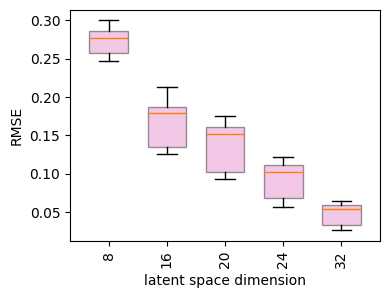

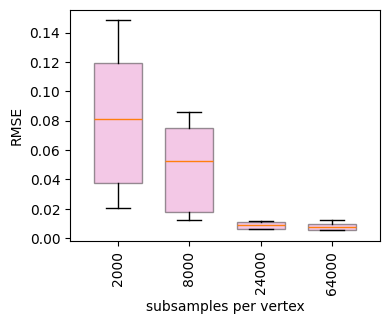

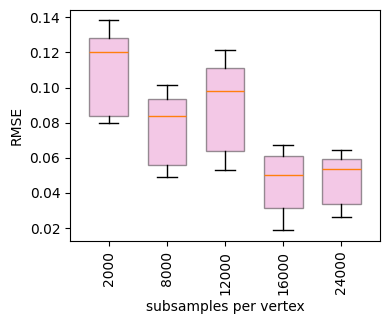

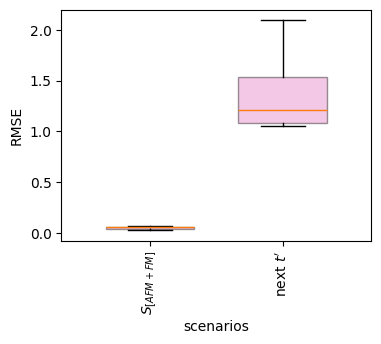

In [4]:
# test vertices only
df = rmse_df.copy()
df = df[~df['train_data'] & ~df['train_phase']]
verteval.plot_rmse_boxplots(df, figsize=(4, 3), train_data=False, plot_dir=plot_dir, plot_name='ae_res2')

### RMSE per vertex (MSE scenarios)

reconstruction RMSE for 1_1_ld32_s24000_r123
mean: 0.007771204776818385, min: 0.0055337100284298, max: 0.0159865485509519
training data only - mean: 0.007771204776818385, min: 0.0055337100284298, max: 0.0159865485509519


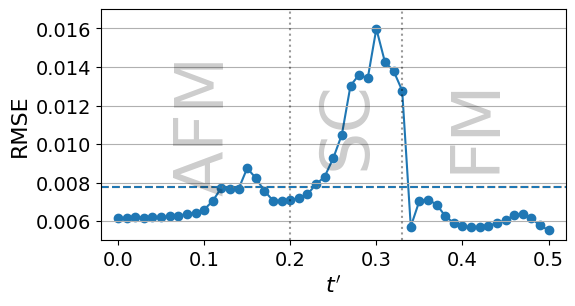

reconstruction RMSE for 2_1_1_ld32_s24000_r123
mean: 0.023504360896572443, min: 0.0054835548049802, max: 0.06428741514296
training data only - mean: 0.01582447853219828, min: 0.0054835548049802, max: 0.0501498918183749
test data only - mean: 0.03447562141710695, min: 0.0060597556595962, max: 0.06428741514296


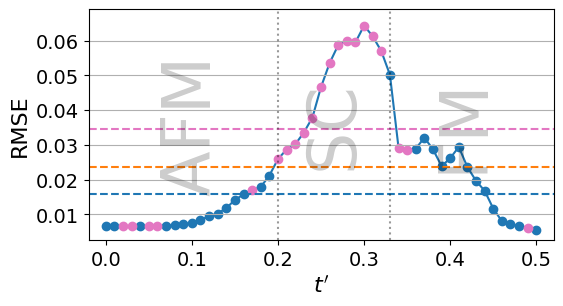

reconstruction RMSE for 2_2_1_ld32_s24000_r123
mean: 0.011346324672715713, min: 0.0058296047811714, max: 0.0376805900382426
training data only - mean: 0.007874428499352064, min: 0.0058585200357042, max: 0.0126556805233798
test data only - mean: 0.014684686377873067, min: 0.0058296047811714, max: 0.0376805900382426


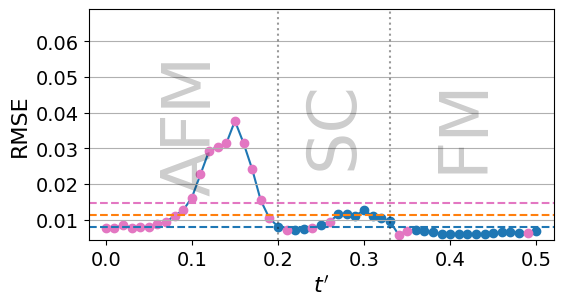

reconstruction RMSE for 2_3_1_ld32_s24000_r123
mean: 0.008694801911262942, min: 0.0062308972393538, max: 0.0133266940365775
training data only - mean: 0.008820276924327054, min: 0.0068315181812861, max: 0.0133266940365775
test data only - mean: 0.008564307897676267, min: 0.0062308972393538, max: 0.0116114379492856


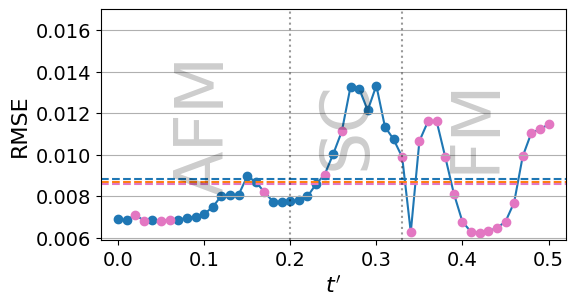

reconstruction RMSE for 3_1_ld32_s24000_r123
mean: 0.016432640288140465, min: 0.0073222943543964, max: 0.0475276224161039
training data only - mean: 0.01015621203985333, min: 0.0085851273079696, max: 0.0117938620285331
test data only - mean: 0.01796347644625928, min: 0.0073222943543964, max: 0.0475276224161039


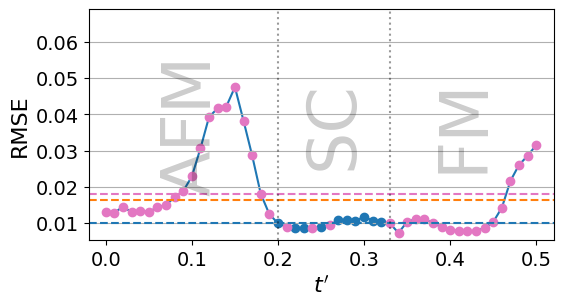

reconstruction RMSE for 3_2_ld32_s24000_r123
mean: 0.05405205146477475, min: 0.0068304631837742, max: 0.1423498029275165
training data only - mean: 0.01428682297744393, min: 0.0069133213537977, max: 0.035640568504099
test data only - mean: 0.07223044163041169, min: 0.0068304631837742, max: 0.1423498029275165


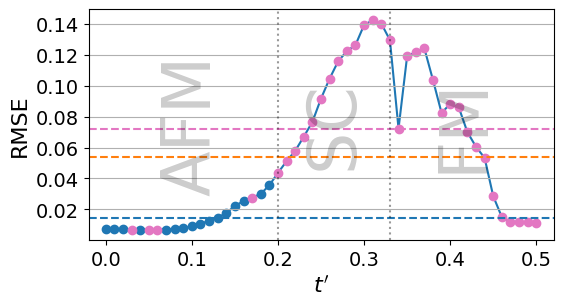

reconstruction RMSE for 3_3_ld32_s24000_r123
mean: 0.01998738447340126, min: 0.0061421676426792, max: 0.0528070905557745
training data only - mean: 0.008324228514100543, min: 0.0061421676426792, max: 0.0299489592649665
test data only - mean: 0.024400470512055586, min: 0.0063116254150922, max: 0.0528070905557745


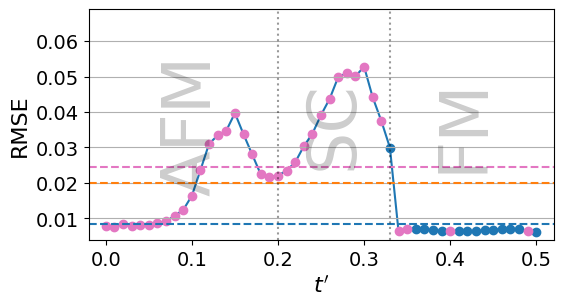

In [16]:
# compare scenario 2 and 3
subset = rmse_df[~rmse_df['contrastive'] & (rmse_df['ld'] == 32) & (rmse_df['s'] == 24000) & (rmse_df['seed'] == 123)]
for (run_id, ld, s, seed), group in subset.groupby(['run_id', 'ld', 's', 'seed']):
    ymax = group['rmse'].max()
    ymax = ymax * 1.05 if ymax > 0.065 else 0.069 if ymax > 0.0165 else 0.017
    verteval.plot_rmse_against_tp(group, f'{run_id}_ld{ld}_s{s}_r{seed}', figsize=(6,3), font_size=16, ymin=0., ymax=ymax,
                                  plot_dir=plot_dir, plot_name=f'ae_rmse_{run_id}_ld{ld}_s{s}_r{seed}')

### RMSE per vertex (subsample count comparison)

reconstruction RMSE for 2_3_1_ld32_s2000_r123
mean: 0.07495438605903545, min: 0.020903182812724, max: 0.1483526802366681
training data only - mean: 0.07406938096126822, min: 0.0236051810736208, max: 0.1321730329857794
test data only - mean: 0.07587479136071336, min: 0.020903182812724, max: 0.1483526802366681


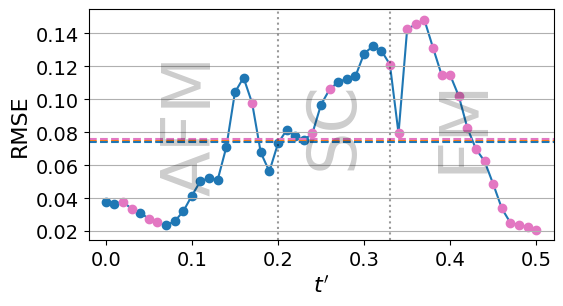

reconstruction RMSE for 2_3_1_ld32_s8000_r123
mean: 0.0395102526324566, min: 0.0106006232180974, max: 0.0862317024515797
training data only - mean: 0.03628252931576299, min: 0.0106006232180974, max: 0.0836478029644731
test data only - mean: 0.042867084881817945, min: 0.0108463012215116, max: 0.0862317024515797


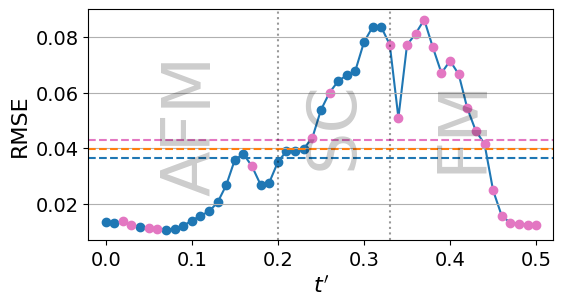

reconstruction RMSE for 2_3_1_ld32_s24000_r123
mean: 0.008694801911262942, min: 0.0062308972393538, max: 0.0133266940365775
training data only - mean: 0.008820276924327054, min: 0.0068315181812861, max: 0.0133266940365775
test data only - mean: 0.008564307897676267, min: 0.0062308972393538, max: 0.0116114379492856


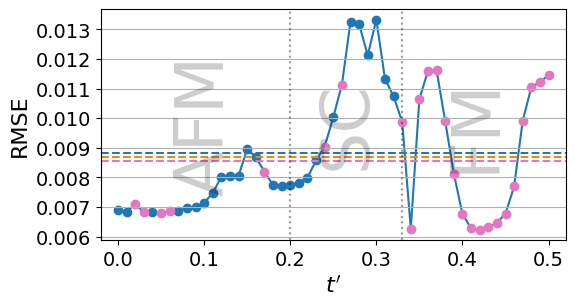

reconstruction RMSE for 2_3_1_ld32_s64000_r123
mean: 0.007519212248283734, min: 0.0053796154634875, max: 0.0123590586240546
training data only - mean: 0.007441814485937974, min: 0.0058319130593045, max: 0.0115952487588708
test data only - mean: 0.007599705921123324, min: 0.0053796154634875, max: 0.0123590586240546


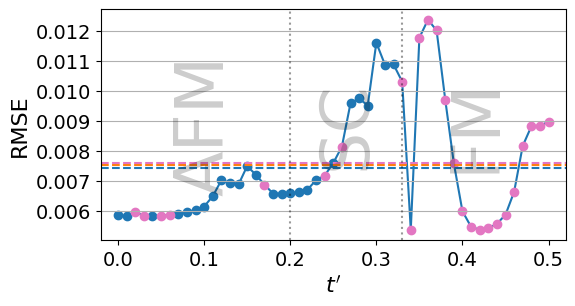

In [11]:
# compare different subsample counts
subset = rmse_df[(rmse_df['run_id'] == '2_3_1') & (rmse_df['ld'] == 32) & (rmse_df['seed'] == 123)]
for (run_id, ld, s, seed), group in subset.groupby(['run_id', 'ld', 's', 'seed']):
    ymax = group['rmse'].max()
    ymax = ymax * 1.05 if ymax > 0.065 else 0.069 if ymax > 0.0165 else 0.017
    verteval.plot_rmse_against_tp(group, f'{run_id}_ld{ld}_s{s}_r{seed}', figsize=(6,3), font_size=16, ymin=0,
                                  plot_dir=plot_dir, plot_name=f'ae_rmse_{run_id}_ld{ld}_s{s}_r{seed}')

### RMSE per vertex (latent space size comparison)

reconstruction RMSE for 2_1_1_ld8_s24000_r123
mean: 0.1698668099740209, min: 0.0563486057711932, max: 0.3000015634505707
training data only - mean: 0.14087214403289694, min: 0.0563486057711932, max: 0.2658101576997915
test data only - mean: 0.2112877613184837, min: 0.0621132165191485, max: 0.3000015634505707


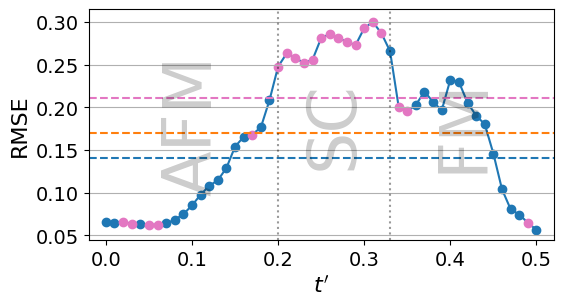

reconstruction RMSE for 2_1_1_ld16_s24000_r123
mean: 0.09762621477913366, min: 0.0241947069982136, max: 0.2133893678188678
training data only - mean: 0.07732067287264986, min: 0.0246249054269442, max: 0.1906810669757207
test data only - mean: 0.12663413178839622, min: 0.0241947069982136, max: 0.2133893678188678


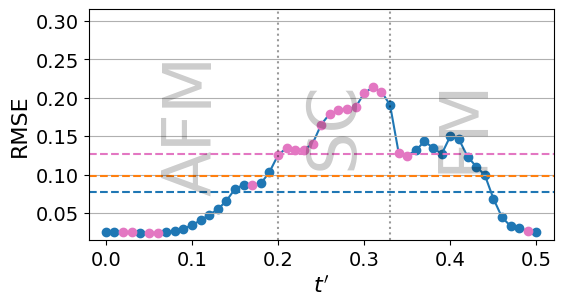

reconstruction RMSE for 2_1_1_ld20_s24000_r123
mean: 0.07475323522414207, min: 0.0184777530350107, max: 0.1753884285875548
training data only - mean: 0.0555143574817175, min: 0.0184777530350107, max: 0.158693618902675
test data only - mean: 0.10223734628474859, min: 0.0192393017482349, max: 0.1753884285875548


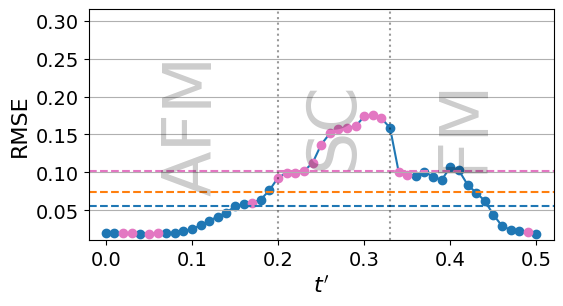

reconstruction RMSE for 2_1_1_ld24_s24000_r123
mean: 0.04687466911381581, min: 0.0066598890367751, max: 0.1212319111065108
training data only - mean: 0.03232695460149508, min: 0.0066598890367751, max: 0.109820575611055
test data only - mean: 0.06765711841713115, min: 0.0079885547434377, max: 0.1212319111065108


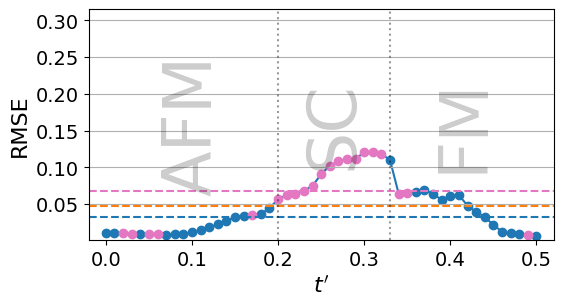

reconstruction RMSE for 2_1_1_ld32_s24000_r123
mean: 0.023504360896572443, min: 0.0054835548049802, max: 0.06428741514296
training data only - mean: 0.01582447853219828, min: 0.0054835548049802, max: 0.0501498918183749
test data only - mean: 0.03447562141710695, min: 0.0060597556595962, max: 0.06428741514296


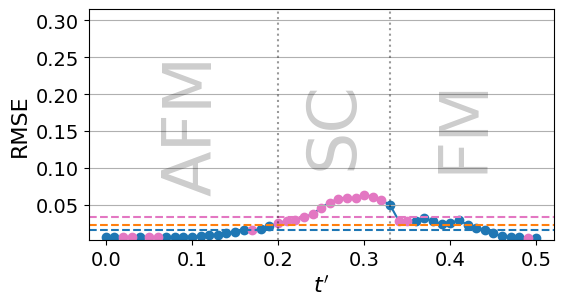

In [17]:
# compare different latent space dimensions
subset = rmse_df[(rmse_df['run_id'] == '2_1_1') & (rmse_df['s'] == 24000) & (rmse_df['seed'] == 123)]
for (run_id, ld, s, seed), group in subset.groupby(['run_id', 'ld', 's', 'seed']):
    verteval.plot_rmse_against_tp(group, f'{run_id}_ld{ld}_s{s}_r{seed}', figsize=(6,3), font_size=16, ymin=0., ymax=subset['rmse'].max() * 1.05,
                                  plot_dir=plot_dir, plot_name=f'ae_rmse_{run_id}_ld{ld}_s{s}_r{seed}')

### RMSE per vertex (contrastive scenarios)

reconstruction RMSE for 1_2_ld32_s24000_r123
mean: 0.06621499723202705, min: 0.0196729876188259, max: 0.1411463894146165
training data only - mean: 0.06621499723202705, min: 0.0196729876188259, max: 0.1411463894146165


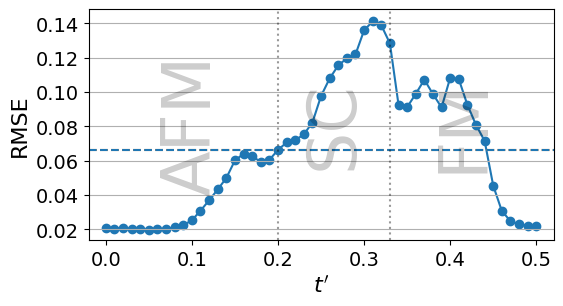

reconstruction RMSE for 2_1_2_ld32_s24000_r123
mean: 0.04314076637809767, min: 0.0097367703815004, max: 0.1144680651146157
training data only - mean: 0.03055552548797525, min: 0.0097367703815004, max: 0.1015223760608776
test data only - mean: 0.06111968193541538, min: 0.0097547245927211, max: 0.1144680651146157


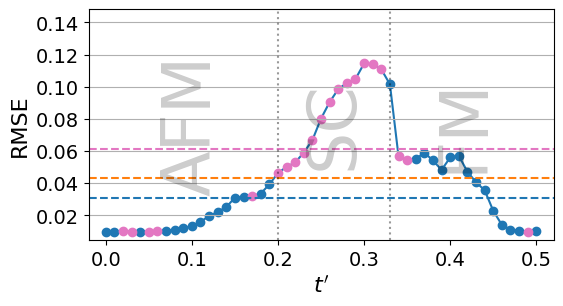

reconstruction RMSE for 2_2_2_ld32_s24000_r123
mean: 0.050307302391825584, min: 0.0211225351602496, max: 0.0908340031611275
training data only - mean: 0.051611620401530764, min: 0.0218633941180148, max: 0.0688014826663395
test data only - mean: 0.04905315045941675, min: 0.0211225351602496, max: 0.0908340031611275


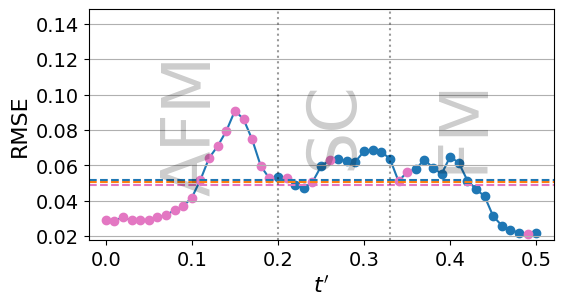

reconstruction RMSE for 2_3_2_ld32_s24000_r123
mean: 0.0670749375226252, min: 0.0209938889883941, max: 0.1295632148579371
training data only - mean: 0.06456942527975959, min: 0.0212229920017746, max: 0.1295632148579371
test data only - mean: 0.0696806702552054, min: 0.0209938889883941, max: 0.1178974209923496


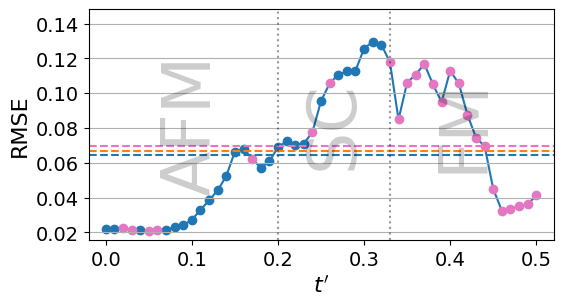

In [13]:
# compare different scenarios (contrastive loss)
subset = rmse_df[rmse_df['contrastive'] & (rmse_df['ld'] == 32) & (rmse_df['s'] == 24000) & (rmse_df['seed'] == 123)]
for (run_id, ld, s, seed), group in subset.groupby(['run_id', 'ld', 's', 'seed']):
    verteval.plot_rmse_against_tp(group, f'{run_id}_ld{ld}_s{s}_r{seed}', figsize=(6,3), font_size=16, ymin=0., ymax=subset['rmse'].max() * 1.05,
                                  plot_dir=None, plot_name=f'ae_rmse_{run_id}_ld{ld}_s{s}_r{seed}')

### RMSE per vertex (data subset comparison)

reconstruction RMSE for 2_3_1_ld32_s24000_r89
mean: 0.009282451287535928, min: 0.0067216572322058, max: 0.0164796945941278
training data only - mean: 0.00905787653532713, min: 0.0070424567666825, max: 0.0143083863254533
test data only - mean: 0.009516009029833076, min: 0.0067216572322058, max: 0.0164796945941278


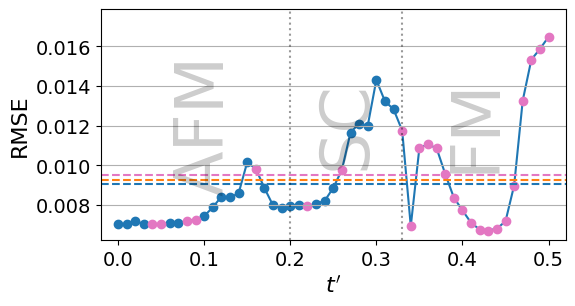

reconstruction RMSE for 2_3_1_ld32_s24000_r106
mean: 0.009300814983985096, min: 0.0061730852283189, max: 0.0168071276140947
training data only - mean: 0.008675445346228099, min: 0.006714334636209, max: 0.0144648165188383
test data only - mean: 0.009951199407252372, min: 0.0061730852283189, max: 0.0168071276140947


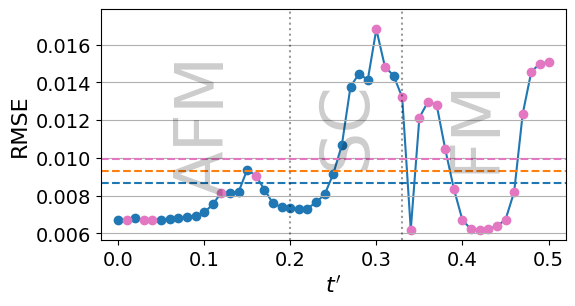

reconstruction RMSE for 2_3_1_ld32_s24000_r123
mean: 0.008694801911262942, min: 0.0062308972393538, max: 0.0133266940365775
training data only - mean: 0.008820276924327054, min: 0.0068315181812861, max: 0.0133266940365775
test data only - mean: 0.008564307897676267, min: 0.0062308972393538, max: 0.0116114379492856


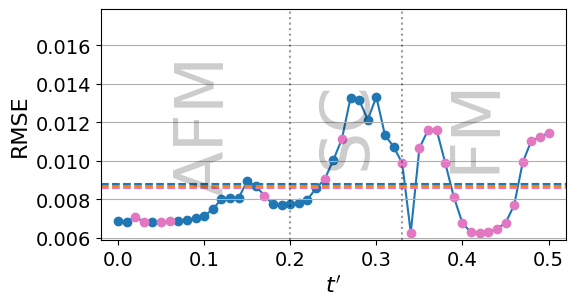

reconstruction RMSE for 2_3_1_ld32_s24000_r140
mean: 0.008541066752332445, min: 0.0059232890609685, max: 0.0170206643150945
training data only - mean: 0.008931284046914331, min: 0.0064498332944307, max: 0.0170206643150945
test data only - mean: 0.00813524076596728, min: 0.0059232890609685, max: 0.0144883402688795


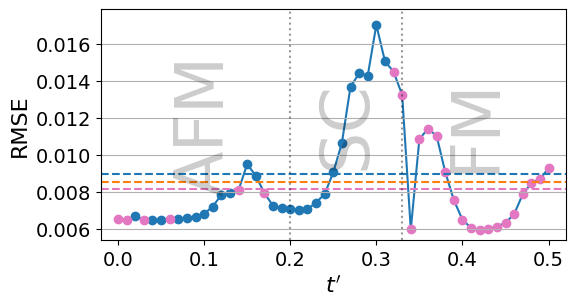

reconstruction RMSE for 2_3_1_ld32_s24000_r157
mean: 0.009279009461839193, min: 0.0069560862513396, max: 0.0166039192293695
training data only - mean: 0.009537040612015607, min: 0.0069560862513396, max: 0.0166039192293695
test data only - mean: 0.009010657065655719, min: 0.0069863755734482, max: 0.0148939207797442


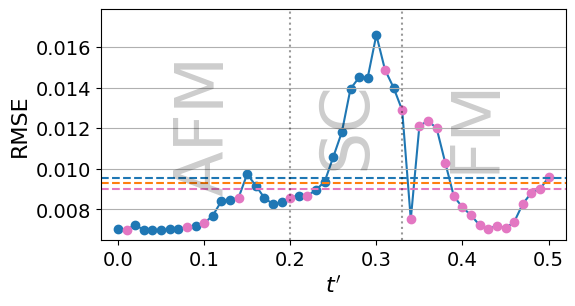

In [14]:
# compare different training subsets
subset = rmse_df[(rmse_df['run_id'] == '2_3_1') & (rmse_df['ld'] == 32) & (rmse_df['s'] == 24000)]
for (run_id, ld, s, seed), group in subset.groupby(['run_id', 'ld', 's', 'seed']):
    verteval.plot_rmse_against_tp(group, f'{run_id}_ld{ld}_s{s}_r{seed}', figsize=(6,3), font_size=16, ymin=0., ymax=subset['rmse'].max() * 1.05,
                                  plot_dir=None, plot_name=f'ae_rmse_{run_id}_ld{ld}_s{s}_r{seed}')

### RMSE per vertex (next vertex prediction)

reconstruction RMSE for 2_1_1_step_ld32_s64000_r123
mean: 1.5499984620120923, min: 0.907381153530362, max: 3.0422552453803604
training data only - mean: 1.6933452890983596, min: 0.907381153530362, max: 3.0422552453803604
test data only - mean: 1.3520433198453425, min: 0.9193642599953856, max: 2.515552918659002


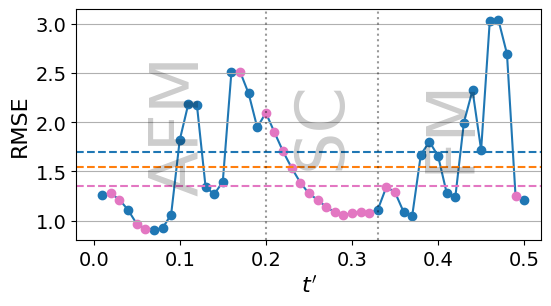

In [15]:
# next vertex prediction
subset = rmse_df[rmse_df['run_id'] == '2_1_1_step']
verteval.plot_rmse_against_tp(subset, f'2_1_1_step_ld32_s64000_r123', figsize=(6,3), font_size=16, ymin=0.,
                              plot_dir=plot_dir, plot_name=f'ae_rmse_2_1_1_step')

## convergence

In [2]:
from pathlib import Path

base_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results_2/'
folders = sorted([f.name for f in Path(base_path).iterdir() if f.is_dir() and not f.name.startswith('.')])
run_ids = ['1_1', '1_2', '2_1_1', '2_1_1_step', '2_1_2', '2_2_1', '2_2_2', '2_3_1', '2_3_2', '3_1', '3_2', '3_3']  # '2_1_1_nextTp'
labels = []
for f in folders:
    fsplit = f.split('_')
    pref, suff = '_'.join(fsplit[:-1]), fsplit[-1]
    labels.append(f"{pref}, {suff}")
tensorboard_data = vis.get_tensorboard_data(base_path, folders, labels)
tensorboard_data.to_csv('tensorboard_data.csv', index=False)

In [16]:
tensorboard_data = pd.read_csv('tensorboard_data.csv')
tensorboard_data['ld'] = tensorboard_data['run'].str.extract(r'.*ld(\d+)').astype(pd.Int32Dtype()).fillna(32)
tensorboard_data['s'] = tensorboard_data['run'].str.extract(r'.*s(\d+)').astype(pd.Int32Dtype()).fillna(24000)
tensorboard_data['seed'] = tensorboard_data['run'].str.extract(r'.*r(\d+)').astype(pd.Int32Dtype()).fillna(123)
tensorboard_data['run'] = tensorboard_data['run'].str.split(',').str[0]

tensorboard_stats = vis.get_tensorboard_statistics(tensorboard_data)
tensorboard_stats

wall time [hours]  epochs  min. loss  \
run        ld s      seed                                         
1_1        32 24000  123               40.99   24999   0.000072   
1_2        32 24000  123               29.98   49999   0.017430   
2_1_1      8  24000  123               24.39   24999   0.023770   
           16 24000  123               24.16   24999   0.008373   
           20 24000  123               24.27   24999   0.004417   
           24 24000  123               24.35   24999   0.001683   
           32 2000   123                2.38   24999   0.003523   
              8000   123                8.31   24999   0.001009   
              12000  123               12.05   24999   0.001852   
              16000  123               15.93   24999   0.000078   
              24000  123               24.38   24999   0.000379   
2_1_1_step 32 64000  123              128.68   24999   1.995136   
2_1_2      32 24000  123               15.41   49999   0.002904   
2_2_1      32 24000  123               20.23   24999   0.000072   
2_2_2      32 24000  123               13.56   49999   0.009826   
2_3_1      32 2000   123                2.15   24999   0.008074   
              8000   123                7.25   24999   0.001666   
              24000  89                20.99   24999   0.000107   
                     106               20.86   24999   0.000113   
                     123               28.92   24999   0.000078   
                     140               21.04   24999   0.000078   
                     157               21.12   24999   0.000085   
              64000  123              408.02   24999   0.000075   
              128000 123             1186.36   18526   0.000057   
2_3_2      32 24000  123               15.51   49999   0.014092   
3_1        32 24000  123                8.26   24999   0.000077   
3_2        32 24000  123               12.81   24999   0.000337   
3_3        32 24000  123               11.27   24999   0.000091   
_2_3_1     32 24000  123               21.02   24999   0.000078   

                           epoch of min. loss  max. epochs w/o decrease  \
run        ld s      seed                                                 
1_1        32 24000  123                22574                      7957   
1_2        32 24000  123                49891                      1035   
2_1_1      8  24000  123                24658                       526   
           16 24000  123                24995                       870   
           20 24000  123                24953                       674   
           24 24000  123                22145                       953   
           32 2000   123                24904                       180   
              8000   123                24668                      1056   
              12000  123                24822                       987   
              16000  123                21948                      2502   
              24000  123                24019                      2832   
2_1_1_step 32 64000  123                24808                       441   
2_1_2      32 24000  123                20281                      1331   
2_2_1      32 24000  123                19716                      6325   
2_2_2      32 24000  123                48288                      3151   
2_3_1      32 2000   123                24977                       178   
              8000   123                24943                       761   
              24000  89                 24551                      6985   
                     106                23436                      7334   
                     123                23323                      4295   
                     140                20869                      4842   
                     157                21770                      2297   
              64000  123                15609                      9368   
              128000 123                15889                      1573   

In [4]:
# as latex table
print(vis.tensorboard_statistics_to_latex(tensorboard_stats))

\begin{table}
    \centering
    \begin{tabular}{lccccc}
        \toprule
        run & \begin{tabular}[c]{@{}c@{}} wall time\\{[hours]}\end{tabular} & min. loss & \begin{tabular}[c]{@{}c@{}}epoch of\\min. loss\end{tabular} & \begin{tabular}[c]{@{}c@{}}epoch of min. loss\\(10\% threshold)\end{tabular} & \begin{tabular}[c]{@{}c@{}}max. epochs\\w/o decrease\end{tabular}\\
        \midrule
        1-1 & 41 & 0.000072 & 22,574 & 7,957 & 22,574 \\
        1-2 & 30 & 0.017430 & 49,891 & 1,035 & 39,344 \\
        2-1-1 & 24 & 0.000379 & 24,019 & 2,832 & 17,170 \\
        2-1-2 & 15 & 0.002904 & 20,281 & 1,331 & 12,850 \\
        2-2-1 & 20 & 0.000072 & 19,716 & 6,325 & 18,949 \\
        2-2-2 & 14 & 0.009826 & 48,288 & 3,151 & 37,298 \\
        2-3-1 & 29 & 0.000078 & 23,323 & 4,295 & 16,690 \\
        2-3-2 & 16 & 0.014092 & 49,349 & 1,971 & 41,767 \\
        3-1 & 8 & 0.000077 & 24,280 & 1,467 & 23,421 \\
        3-2 & 13 & 0.000337 & 24,221 & 1,000 & 22,469 \\
        3-3 & 11 & 0.000091 &

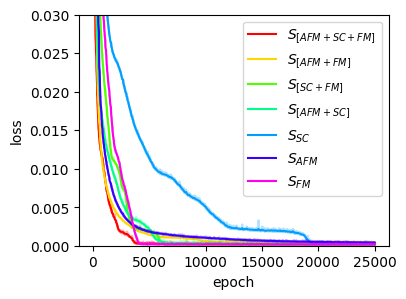

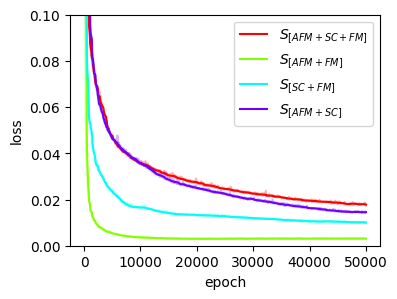

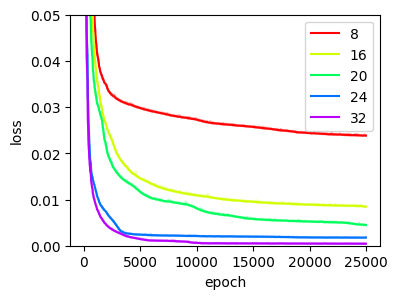

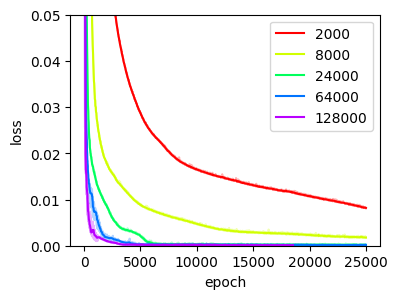

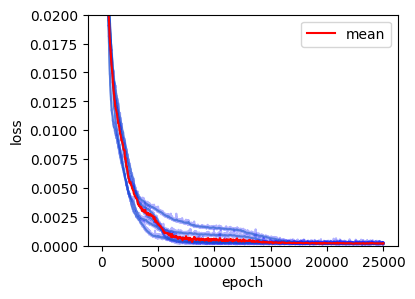

In [20]:
verteval.plot_loss_progress(tensorboard_data.dropna(), y_maxs=(0.03, 0.1, 0.05, 0.05, 0.02), figsize=(4,3), log=False, 
                            plot_dir=plot_dir, plot_name='ae_converge')

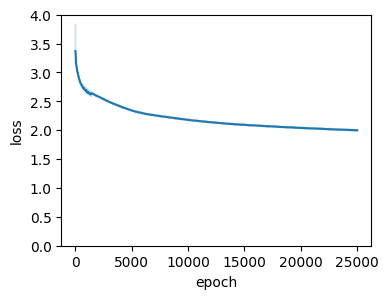

In [36]:
# next vertex prediction
import matplotlib.pyplot as plt
data = tensorboard_data[tensorboard_data['run'] == '2_1_1_step'].sort_values(by=['run', 'ld', 's', 'seed'])
fig, ax = plt.subplots(figsize=(4,3))
ax.plot(data['epoch'], verteval.gaussian_filter1d(data['value'], 4), color=vis.COLORS[2])
ax.plot(data['epoch'], data['value'], color=vis.COLORS[2], alpha=0.2)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_ylim((0., 4.))
plt.savefig(plot_dir / f'ae_converge_step.png', bbox_inches='tight', dpi=300)
plt.show()

## compare phase classifier models

In [21]:
classification_df.set_index(['run_id', 'ld', 's', 'seed'])

model  \
run_id      ld s     seed                                                      
2_1_1       32 8000  123   RandomForestClassifier(n_jobs=-1, random_state...   
2_1_2       32 24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
2_3_1       32 24000 89    RandomForestClassifier(n_jobs=-1, random_state...   
3_2         32 24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
2_3_1       32 8000  123   RandomForestClassifier(n_jobs=-1, random_state...   
               64000 123   RandomForestClassifier(n_jobs=-1, random_state...   
               24000 106   RandomForestClassifier(n_jobs=-1, random_state...   
2_2_2       32 24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
2_1_1       8  24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
2_3_2       32 24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
3_1         32 24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
1_1         32 24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
2_1_1       20 24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
2_2_1       32 24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
3_3         32 24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
2_1_1       32 24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
                     123   NeuralNetClassifier(batch_size=4096, num_worke...   
                     123   RandomForestRegressor(n_jobs=-1, random_state=...   
                     123                                       StandardSVC()   
                     123   PolynomialRegression(method=spline, degree=3, ...   
                     123       PolynomialRegression(method=spline, degree=3)   
               12000 123   RandomForestClassifier(n_jobs=-1, random_state...   
no_encoding 32 24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
2_1_1       32 16000 123   RandomForestClassifier(n_jobs=-1, random_state...   
2_3_1       32 24000 157   RandomForestClassifier(n_jobs=-1, random_state...   
2_1_1       24 24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
1_2         32 24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
2_1_1       32 2000  123   RandomForestClassifier(n_jobs=-1, random_state...   
2_3_1       32 24000 140   RandomForestClassifier(n_jobs=-1, random_state...   
2_1_1       16 24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
2_3_1       32 24000 123   RandomForestClassifier(n_jobs=-1, random_state...   
               2000  123   RandomForestClassifier(n_jobs=-1, random_state...   

                                acc        f1      rmse  \
run_id      ld s     seed                                 
2_1_1       32 8000  123   0.987635  0.987635       NaN   
2_1_2       32 24000 123   0.990148  0.990148       NaN   
2_3_1       32 24000 89    0.986965  0.986965       NaN   
3_2         32 24000 123   0.988195  0.988195       NaN   
2_3_1       32 8000  123   0.986736  0.986736       NaN   
               64000 123   0.987707  0.987707       NaN   
               24000 106   0.987117  0.987117       NaN   
2_2_2       32 24000 123   0.989794  0.989794       NaN   
2_1_1       8  24000 123   0.985030  0.985030       NaN   
2_3_2       32 24000 123   0.989871  0.989871       NaN   
3_1         32 24000 123   0.986625  0.986625       NaN   
1_1         32 24000 123   0.987714  0.987714       NaN   
2_1_1       20 24000 123   0.988506  0.988506       NaN   
2_2_1       32 24000 123   0.987411  0.987411       NaN   
3_3         32 24000 123   0.988236  0.988236       NaN   
2_1_1       32 24000 123   0.988393  0.988393       NaN   
                     123   0.648557  0.648557       NaN   
                     123   0.952875  0.952875  0.021544   
                     123   0.713008  0.713008       NaN   
                     123   0.393721  0.393721  0.130046   
                     123   0.418391  0.418391  0.121

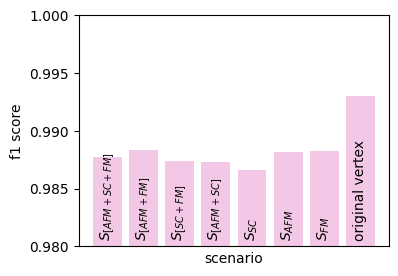

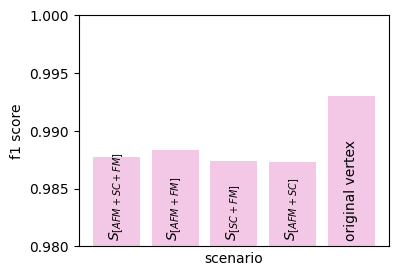

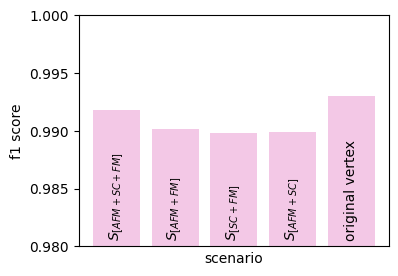

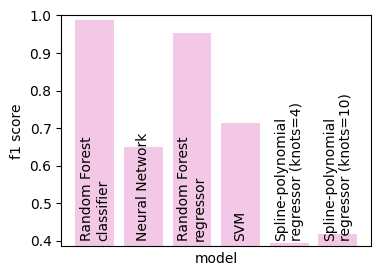

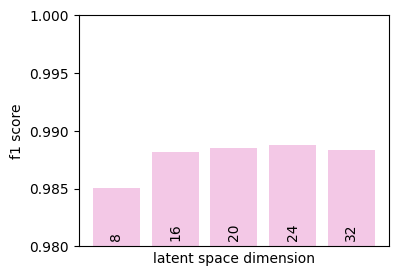

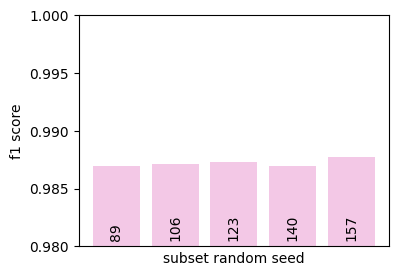

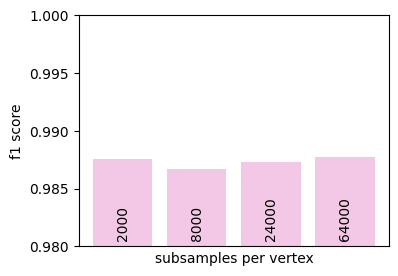

In [37]:
verteval.plot_classification_results(classification_df, figsize=(4, 3), plot_dir=plot_dir, plot_name='pc_res')

In [24]:
print(df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{rrrlrrrrr}
\toprule
tp & rmse & train_data & run_id & ld & s & seed & contrastive & train_phase \\
\midrule
0.200 & 0.044 & False & 3_2 & 32 & 24000 & 123 & False & False \\
0.210 & 0.051 & False & 3_2 & 32 & 24000 & 123 & False & False \\
0.220 & 0.058 & False & 3_2 & 32 & 24000 & 123 & False & False \\
0.230 & 0.067 & False & 3_2 & 32 & 24000 & 123 & False & False \\
0.240 & 0.077 & False & 3_2 & 32 & 24000 & 123 & False & False \\
0.250 & 0.092 & False & 3_2 & 32 & 24000 & 123 & False & False \\
0.260 & 0.105 & False & 3_2 & 32 & 24000 & 123 & False & False \\
0.270 & 0.116 & False & 3_2 & 32 & 24000 & 123 & False & False \\
0.280 & 0.122 & False & 3_2 & 32 & 24000 & 123 & False & False \\
0.290 & 0.126 & False & 3_2 & 32 & 24000 & 123 & False & False \\
0.300 & 0.139 & False & 3_2 & 32 & 24000 & 123 & False & False \\
0.310 & 0.142 & False & 3_2 & 32 & 24000 & 123 & False & False \\
0.320 & 0.140 & False & 3_2 & 32 & 24000 & 123 & False & False \\
0.330 & 0.130 & Fa

2_1_1_ld32_s8000_r123


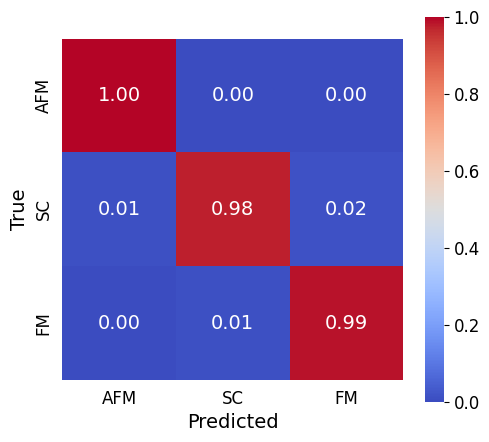

2_1_2_ld32_s24000_r123


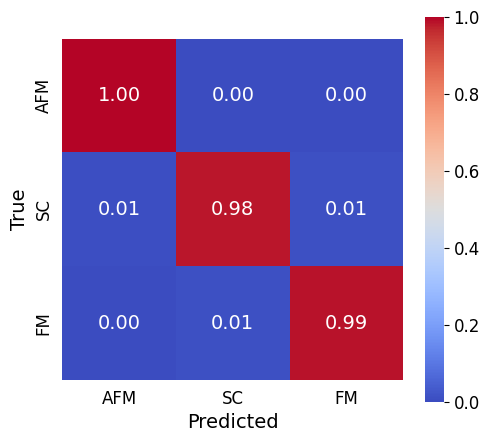

2_3_1_ld32_s24000_r89


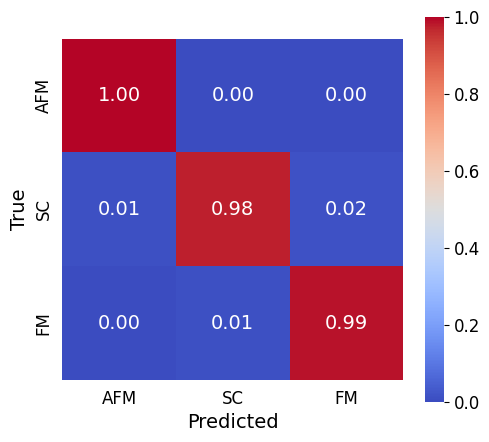

3_2_ld32_s24000_r123


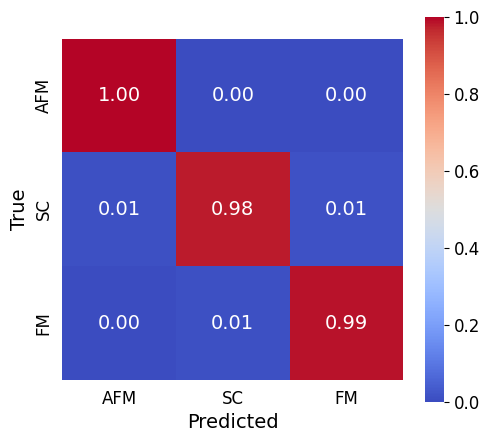

2_3_1_ld32_s8000_r123


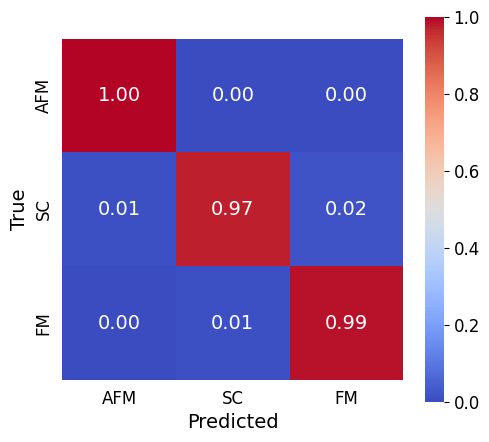

2_3_1_ld32_s64000_r123


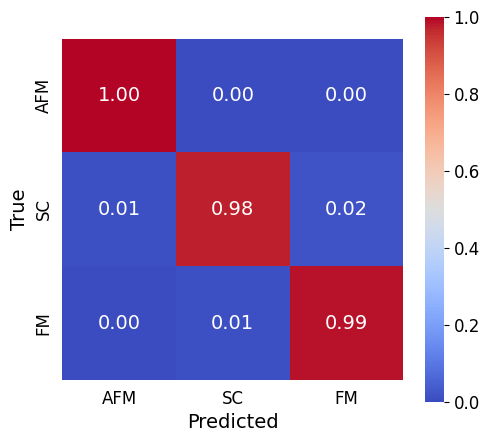

2_3_1_ld32_s24000_r106


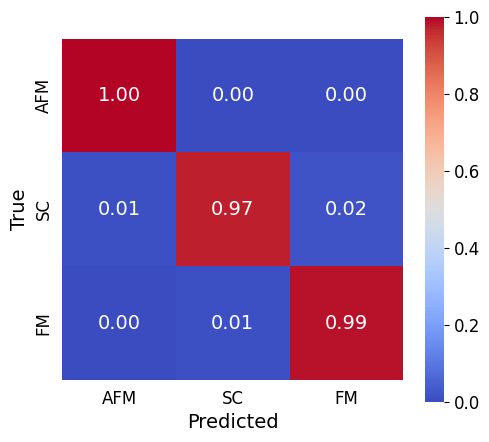

2_2_2_ld32_s24000_r123


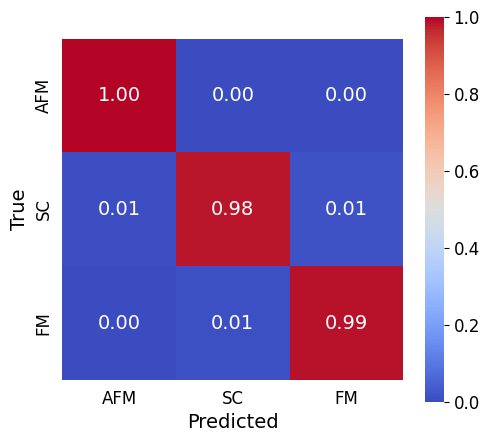

2_1_1_ld8_s24000_r123


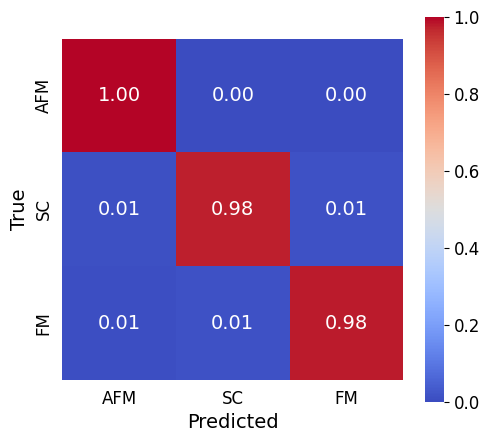

2_3_2_ld32_s24000_r123


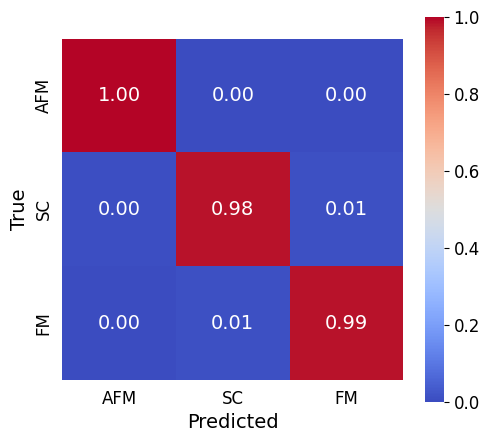

3_1_ld32_s24000_r123


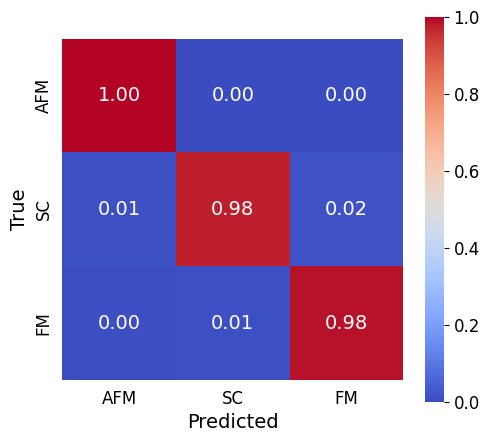

1_1_ld32_s24000_r123


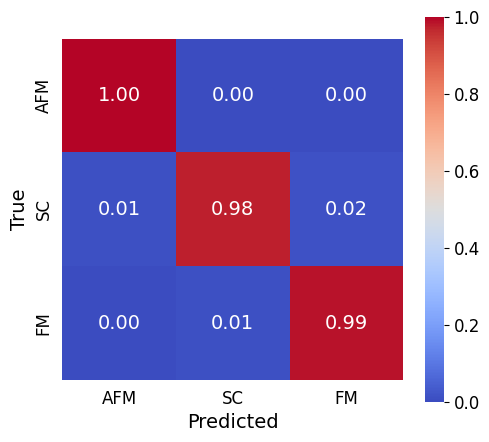

2_1_1_ld20_s24000_r123


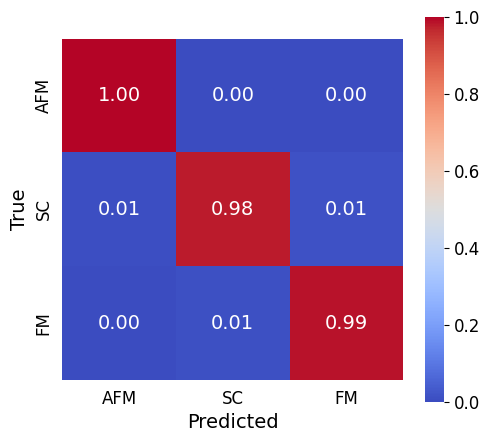

2_2_1_ld32_s24000_r123


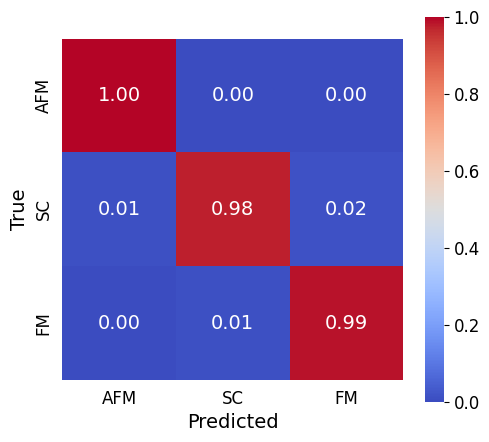

3_3_ld32_s24000_r123


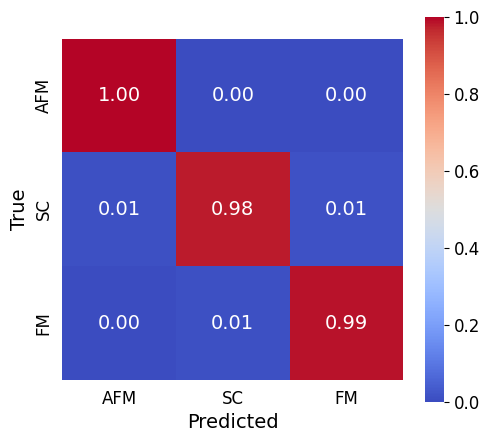

2_1_1_ld32_s24000_r123


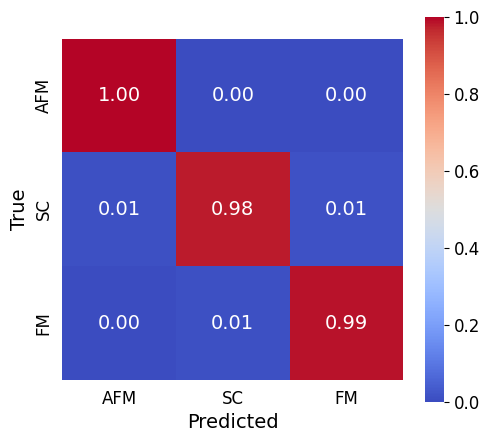

2_1_1_ld32_s24000_r123


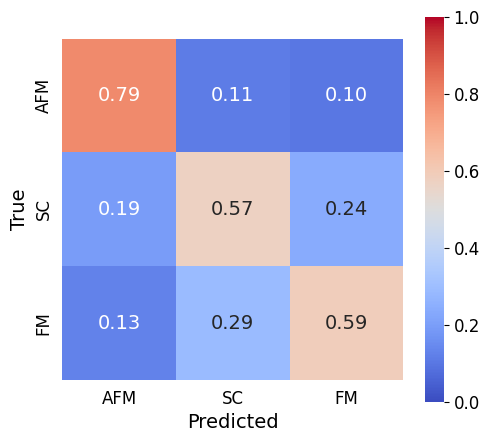

2_1_1_ld32_s24000_r123


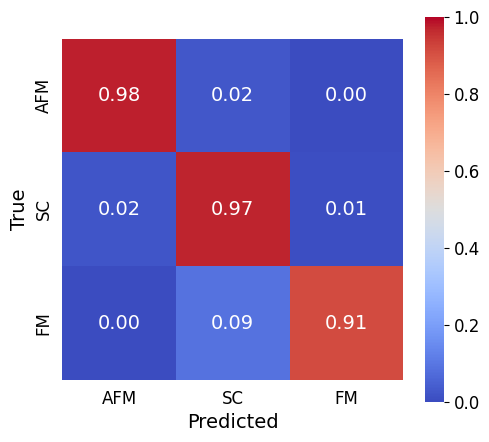

2_1_1_ld32_s24000_r123


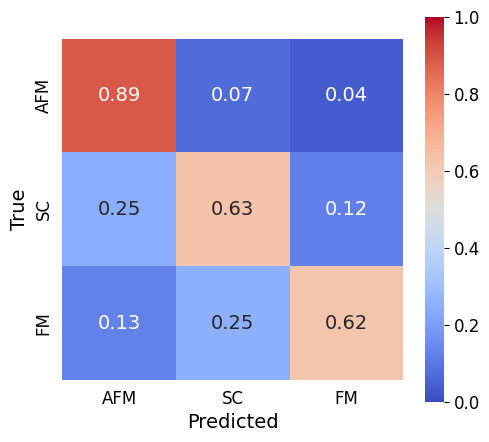

2_1_1_ld32_s24000_r123


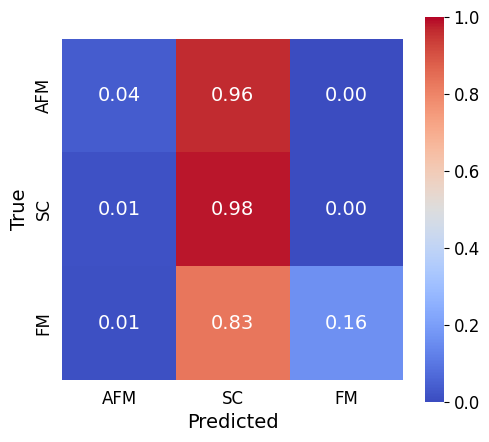

2_1_1_ld32_s24000_r123


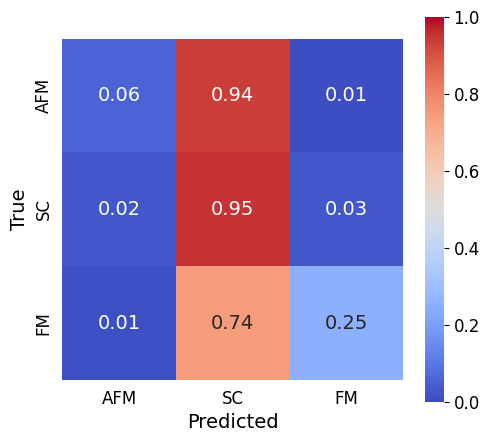

2_1_1_ld32_s12000_r123


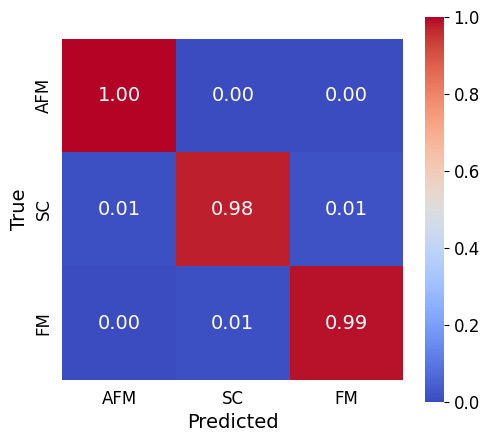

no_encoding_ld32_s24000_r123


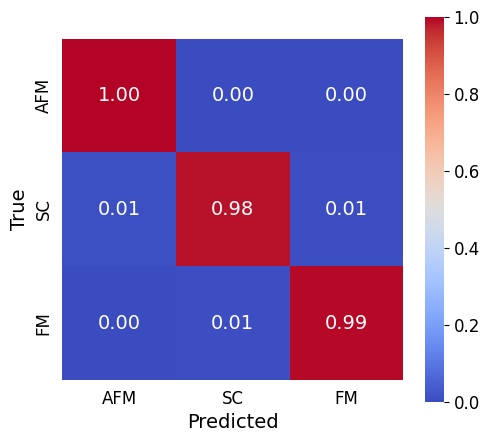

2_1_1_ld32_s16000_r123


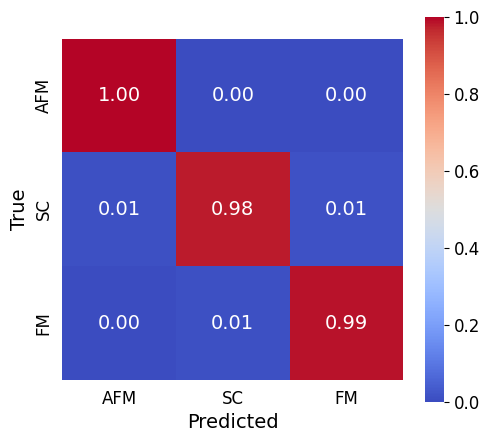

2_3_1_ld32_s24000_r157


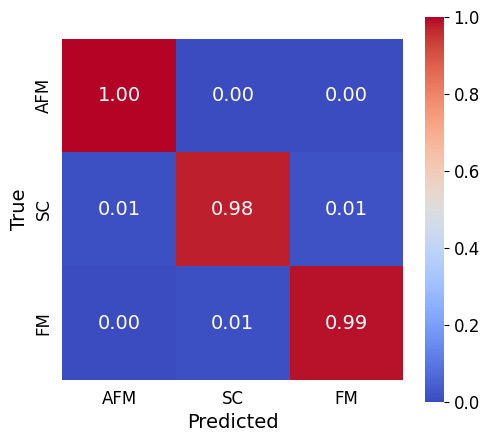

2_1_1_ld24_s24000_r123


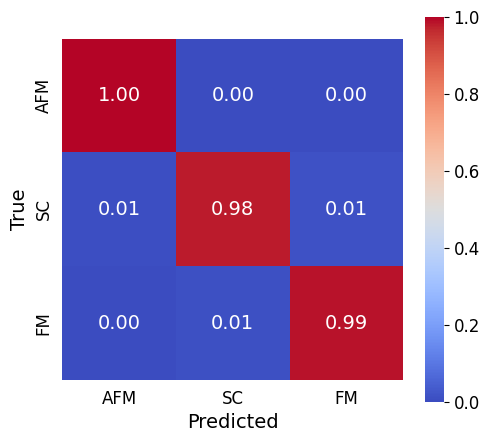

1_2_ld32_s24000_r123


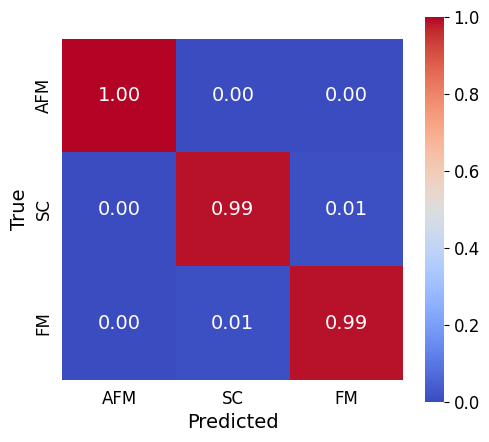

2_1_1_ld32_s2000_r123


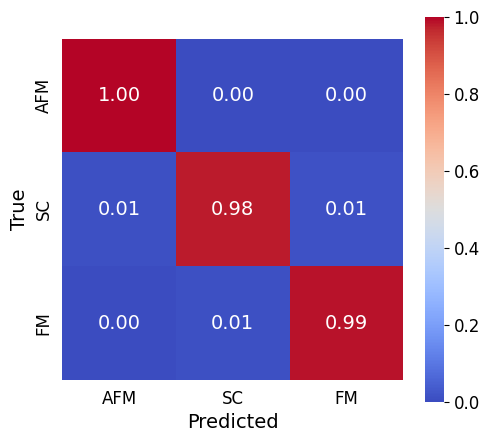

2_3_1_ld32_s24000_r140


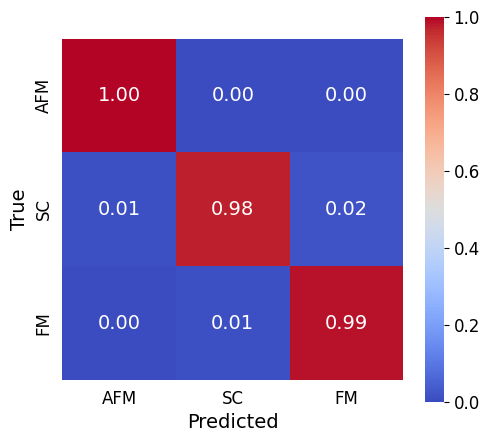

2_1_1_ld16_s24000_r123


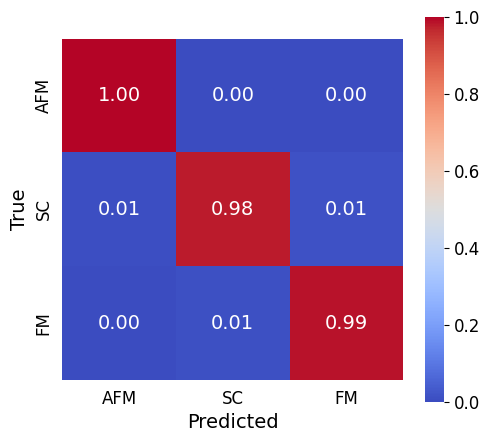

2_3_1_ld32_s24000_r123


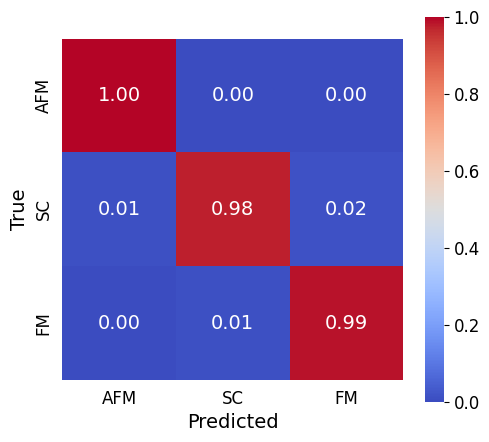

2_3_1_ld32_s2000_r123


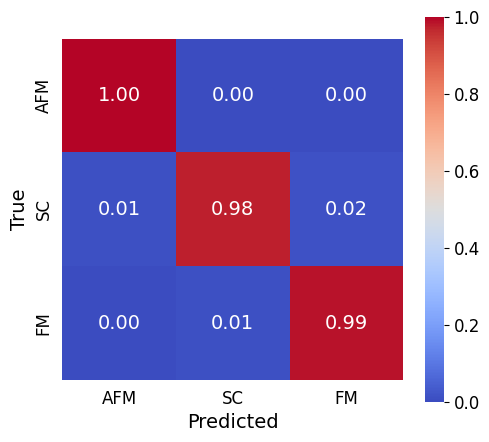

In [25]:
labels = [label.upper() for label in list(AutoEncoderVertexDataset.phase_borders.keys())]
for i, row in classification_df.iterrows():
    vertvis.print_conf_mat(row['conf_mat'], f"{row['run_id']}_ld{row['ld']}_s{row['s']}_r{row['seed']}", labels)

## inspect regression results

PolynomialRegression(method=spline, degree=3)


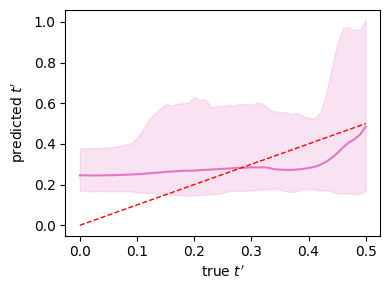

PolynomialRegression(method=spline, degree=3, n_knots=4)


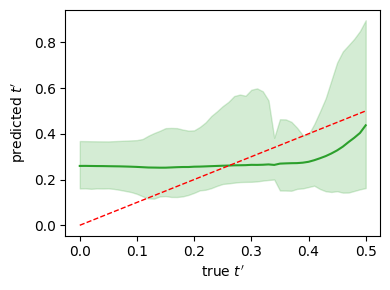

RandomForestRegressor(n_jobs=-1, random_state=125)


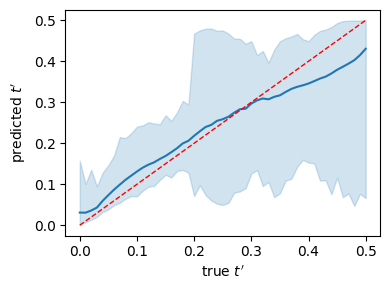

In [38]:
verteval.analyse_regression(regression_df, plot_dir=plot_dir, plot_name='reg_anal')

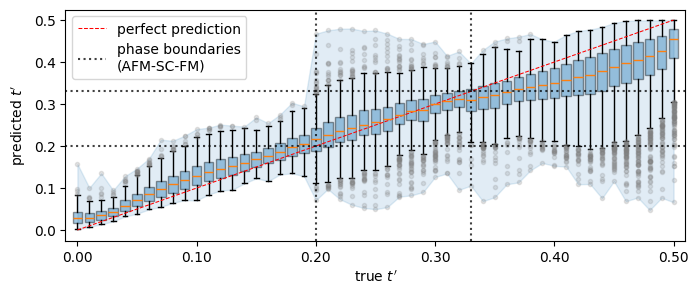

In [39]:
df = regression_df[(regression_df['run_id'] == '2_1_1') & (regression_df['ld'] == 32) 
                    & (regression_df['s'] == 24000) & (regression_df['seed'] == 123)]
df = df[df['model'].str.startswith('RandomForestRegressor')].sort_values(['model', 'tp'])

verteval.analyse_regression_box(df, plot_dir=plot_dir, plot_name='reg_box')

## regression forest feature importance

In [2]:
rf_path_encoded = '/gpfs/data/fs71925/shepp123/PhysML/slurm/vertex_24x6/models/1_1_ld32_RandomForestClassifier(n_jobs=-1, random_state=125).pkl'
rf_path_cl = '/gpfs/data/fs71925/shepp123/PhysML/slurm/vertex_24x6/models/1_2_ld32_RandomForestClassifier(n_jobs=-1, random_state=125).pkl'
rf_path_o = '/gpfs/data/fs71925/shepp123/PhysML/slurm/vertex_24x6/no_encoding_ld0_00_RandomForestClassifier.pkl'
encoder_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results_2/1_1_ld32'
cl_path = '/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results_2/1_2_ld32'

fia = verteval.FeatureImportanceAnalysis(data_dir, plot_dir=None)
fia.load_vertices()
rf_model_encoded = fia.load_rf(rf_path_encoded)
rf_model_cl = fia.load_rf(rf_path_cl)
rf_model_o = fia.load_rf(rf_path_o)

Loading vertex files:   0%|          | 0/51 [00:00<?, ?it/s]

In [ ]:
n_samples = 4800
fia.create_dataset(n_samples)
X_test_encoded, y_test_encoded = fia.load_test_data(encoder_path)
X_test_cl, y_test_cl = fia.load_test_data(cl_path)
X_test_o, y_test_o = fia.load_test_data(None)

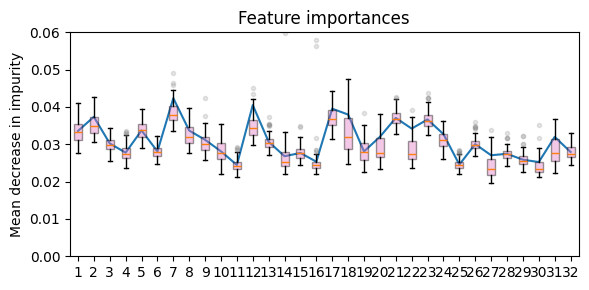

In [72]:
feat_importances_encoded = fia.get_feat_importances(rf_model_encoded)
fia.plot_feat_importances(feat_importances_encoded, box=True, ymax=0.06, plot_name='feat_imp_enc')

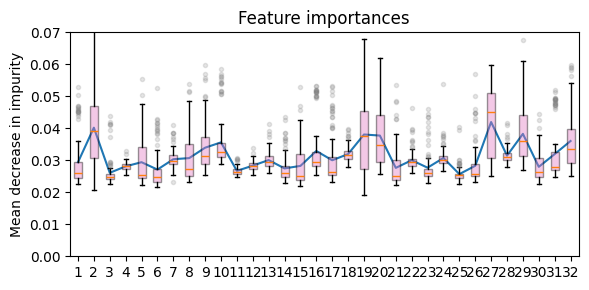

In [73]:
feat_importances_cl = fia.get_feat_importances(rf_model_cl)
fia.plot_feat_importances(feat_importances_cl, box=True, ymax=0.07, plot_name='feat_imp_cl')

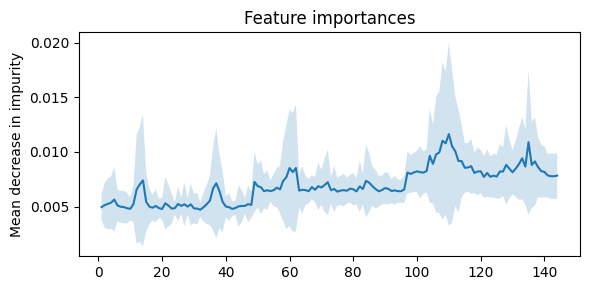

In [74]:
feat_importances_o = fia.get_feat_importances(rf_model_o)
fia.plot_feat_importances(feat_importances_o, box=False, plot_name='feat_imp_o')

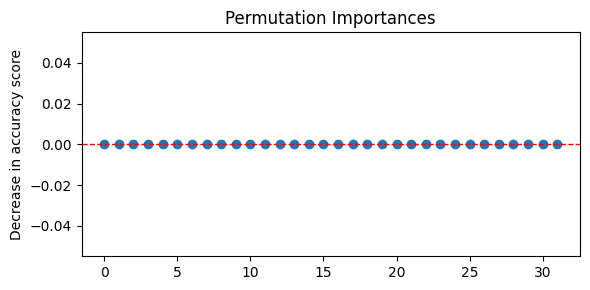

In [61]:
perm_importances_encoded = fia.compute_perm_importances(rf_model_encoded, X_test_encoded, y_test_encoded, n_repeats=1)
fia.plot_perm_importances(perm_importances_encoded, X_test_encoded, scatter=True, plot_name='perm_imp_enc')

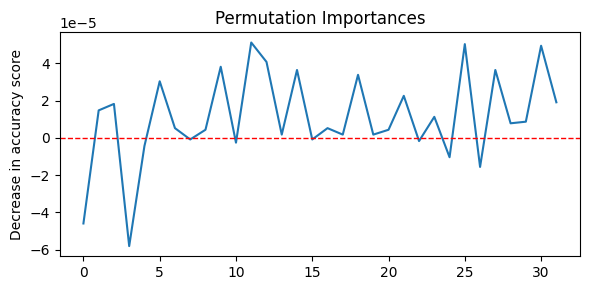

In [64]:
perm_importances_cl = fia.compute_perm_importances(rf_model_cl, X_test_cl, y_test_cl, n_repeats=1)
fia.plot_perm_importances(perm_importances_cl, X_test_cl, scatter=False, plot_name='perm_imp_cl')

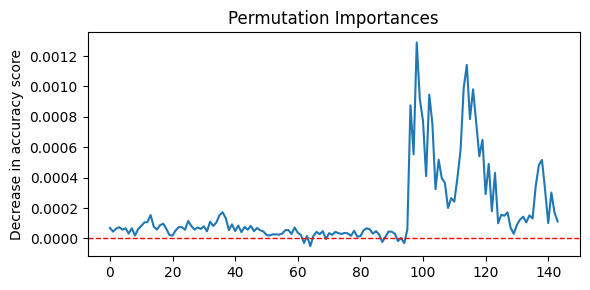

In [65]:
perm_importances_o = fia.compute_perm_importances(rf_model_o, X_test_o, y_test_o, n_repeats=1)
fia.plot_perm_importances(perm_importances_o, X_test_o, scatter=False, plot_name='perm_imp_o')

## compare vertex reconstructions

In [2]:
base_path = Path('/gpfs/data/fs71925/shepp123/PhysML/saves/vertex_24x6/run_results_2/')
vertex_path_dict = {float(fp.stem[2:6]): fp for fp in data_dir.glob('*.h5')}

In [4]:
# set the run and tp-parameter for which you want to comparte original and reconstruction
runs_to_plot = ['2_1_1_step_s64000']
tp_to_plot = [0.06, 0.17, 0.47]

vertices = [AutoEncoderVertex24x6Dataset.load_from_file(vertex_path_dict[tp]) for tp in tp_to_plot]
predictions = {run_id: [np.load(base_path / run_id / 'predictions' / (vertex_path_dict[tp].stem + '.npy')) for tp in tp_to_plot] 
               for run_id in runs_to_plot}

Prediction of vertex(2_1_1_step_s64000, tp=0.06)
at ($k_{1_x}=18$, $k_{1_y}=18$, $k_{3_x}=18$, $k_{3_y}=18$)
Prediction of vertex(2_1_1_step_s64000, tp=0.17)
at ($k_{1_x}=18$, $k_{1_y}=18$, $k_{3_x}=18$, $k_{3_y}=18$)
Prediction of vertex(2_1_1_step_s64000, tp=0.47)
at ($k_{1_x}=18$, $k_{1_y}=18$, $k_{3_x}=18$, $k_{3_y}=18$)


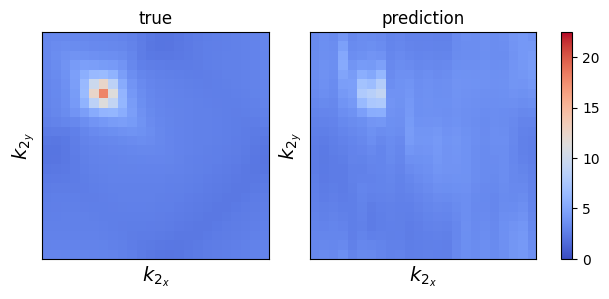

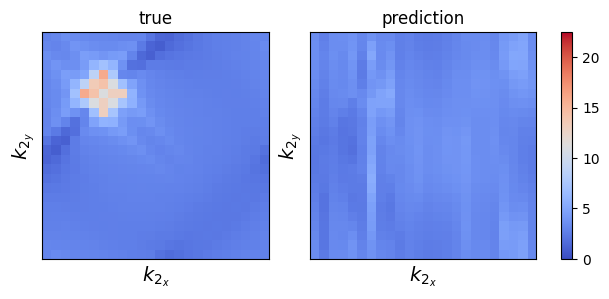

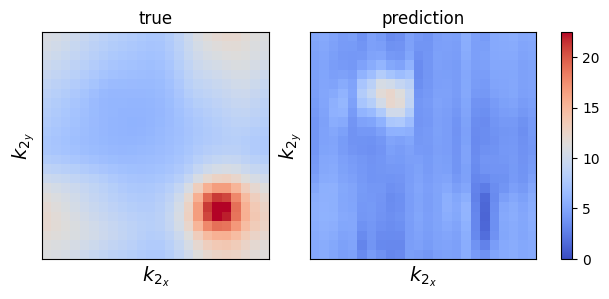

In [29]:
i = 18
axis = 3
nrows, ncols = 1, 2
slice_at = (i, i, i, i)
other_ks = set(range(1,4)) - {(axis + 1) // 2}
params_str = ', '.join([f'$k_{{{k}_{c}}}={sl}$' for (k, c), sl 
                        in zip([(k, c) for k in other_ks for c in ['x', 'y']], slice_at)])

for run_id, preds in predictions.items():
    for tp, true, pred in zip(tp_to_plot, vertices, preds):
        fn = vertex_path_dict[tp].stem
        true_slice = vertvis.get_mat_slice(true, axis, slice_at)
        pred_slice = vertvis.get_mat_slice(pred, axis, slice_at)
        plot_data = {'true': true_slice, 'prediction': pred_slice}
        print(f'Prediction of vertex({run_id}, tp={tp})\nat ({params_str})')
        vertvis.plot_compare_grid(plot_data, nrows, ncols, axis, None, figsize=(6, 4), vmin=0.0, vmax=22.5,
                                  plot_name=f'vert_compare_{run_id}_tp{tp:.2f}_i{i}_axis{axis}')